# US Crude Oil & Distillate — Supply/Demand Balance Model

A weekly S/D balance sheet for the US crude oil and distillate (diesel / heating oil) markets, built on EIA *Weekly Petroleum Status Report* data. It works like a financial balance sheet for physical oil: track what is produced, imported, exported and consumed each week, and whether the imbalance is building or draining inventories.

**Core insight:** when supply and demand fall out of balance, prices have to move to correct it. Model the imbalance before the market fully prices it in and you have a tradeable view.

**How to run:** paste a free EIA API key ([eia.gov/opendata](https://www.eia.gov/opendata)) into `EIA_API_KEY` in the config cell — or set the `EIA_API_KEY` environment variable — then *Run All*. With no key, the notebook runs end-to-end on a bundled **synthetic sample dataset** calibrated to realistic market levels, and every output is stamped accordingly.

| Phase | Section | Deliverable |
|---|---|---|
| 1 | Data + inventory charts | 10+ years of weekly data; level vs 5-yr seasonal average |
| 2 | Balance sheet | implied vs actual stock change, adjustment diagnostic |
| 3 | Seasonal analysis | surplus / deficit vs 5-yr norm — the core signal |
| 4 | Projection + scenarios | 12-week forward view, what-if tool |
| 5 | Market view | explicit written view + one-page PDF |
| 6 | Extensions | PADD regional layer · price-signal backtest · PADD map |

In [1]:
# ── Core imports & display settings ─────────────────────────────────────────
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

## 0 · Configuration

Set the API key, history depth and projection horizon here.

**Units convention** — the single most common data error in this dataset: flows are **Mb/d** (**million** barrels *per day*), inventory levels are **Mb** (**million** barrels, total). Converting a weekly flow imbalance into a stock change means multiplying by **7**. (EIA's API delivers these series in *thousand* barrels — MBBL — so the fetch layer normalizes ÷1000 on the way in; see `DECISIONS.md` #24. Prices are $ series and are never scaled.)

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
from pathlib import Path
if Path(".env").exists():
    for line in Path(".env").read_text().splitlines():
        if "=" in line and not line.startswith("#"):
            k, v = line.split("=", 1)
            os.environ.setdefault(k.strip(), v.strip())
EIA_API_KEY   = os.environ.get("EIA_API_KEY", "YOUR_EIA_API_KEY_HERE")  # free key: eia.gov/opendata
START_DATE    = "2015-01-01"   # 10+ years of history (set earlier for more depth)
HORIZON_WEEKS = 12             # forward projection length (spec: 8-12 weeks)

DATA_DIR   = Path("data");   DATA_DIR.mkdir(exist_ok=True)
CHART_DIR  = Path("charts"); CHART_DIR.mkdir(exist_ok=True)
LIVE_CACHE = DATA_DIR / "eia_live_cache.csv"
SAMPLE_CSV = DATA_DIR / "sample_weekly_data.csv"
ONEPAGER   = Path("weekly_market_view.pdf")

DATA_MODE = "UNSET"  # set by load_data(): LIVE / CACHED / SAMPLE

# UNIT CONVENTION (the #1 data trap):
#   flows  = Mb/d  (MILLION barrels per day)
#   stocks = Mb    (MILLION barrels, total level)
#   weekly stock change implied by flows = (supply - demand) * 7
# EIA's API serves these as THOUSAND barrels (units "MBBL"/"MBBL/D"); the fetch
# layer divides by 1000 so live data lands on the same scale as everything
# here. Price series ($/bbl, $/gal) are never scaled.
MBD, MB = "Mb/d", "Mb"

## 1 · The balance-sheet framework

Everything hangs off one identity:

$$\text{Supply} - \text{Demand} = \Delta\,\text{Inventory}$$

Eleven weekly EIA series cover it — six for crude, five for distillate — each tagged with its role in the identity. Choices worth noting: crude stocks are **commercial, excluding the SPR** (`WCESTUS1`), because SPR moves are policy rather than market; imports and exports are kept **gross** on opposite sides of the balance rather than netted; refinery demand is **net crude input in Mb/d** (a volume, not the utilization percentage); and *product supplied* is EIA's demand **proxy** — it measures disappearance from primary storage, not metered final consumption. Cushing is a sub-component of total crude stocks (the WTI futures delivery point) and is tracked as a level indicator, not a separate balance line.

In [3]:
# ── Series catalog: the balance-sheet framework + extension layers ──────────
# role = how the series enters the model:
#   supply / demand / level / level*  -> the S/D identity  (Supply − Demand = ΔInventory)
#   regional -> PADD view layer: components of a national total. They are NEVER
#               added to the balance — that would double-count the national row.
#   price    -> $ series for the signal backtest. Prices are NOT volumes: the
#               ×7 Mb/d→Mb/wk conversion must NEVER touch them.
SERIES = {
    # ---- crude (6 series) ----
    "WCRFPUS2":              dict(short="c_prod", commodity="crude", role="supply",  unit="Mb/d",
                                  name="US crude oil field production"),
    "WCEIMUS2":              dict(short="c_imp",  commodity="crude", role="supply",  unit="Mb/d",
                                  name="Crude oil imports (gross)"),
    "WCREXUS2":              dict(short="c_exp",  commodity="crude", role="demand",  unit="Mb/d",
                                  name="Crude oil exports"),
    "WCRRIUS2":              dict(short="runs",   commodity="crude", role="demand",  unit="Mb/d",
                                  name="Refiner net input of crude (refinery runs)"),
    "WCESTUS1":              dict(short="c_stk",  commodity="crude", role="level",   unit="Mb",
                                  name="Commercial crude stocks (EXCLUDING SPR)"),
    "W_EPC0_SAX_YCUOK_MBBL": dict(short="cush",   commodity="crude", role="level*",  unit="Mb",
                                  name="Cushing, OK crude stocks (sub-component)"),
    # ---- distillate (5 series) ----
    "WDIRPUS2":              dict(short="d_prod", commodity="distillate", role="supply", unit="Mb/d",
                                  name="Distillate production (refiner + blender net)"),
    "WDIIMUS2":              dict(short="d_imp",  commodity="distillate", role="supply", unit="Mb/d",
                                  name="Distillate imports"),
    "WDIEXUS2":              dict(short="d_exp",  commodity="distillate", role="demand", unit="Mb/d",
                                  name="Distillate exports"),
    "WDIUPUS2":              dict(short="d_dem",  commodity="distillate", role="demand", unit="Mb/d",
                                  name="Distillate product supplied (demand proxy)"),
    "WDISTUS1":              dict(short="d_stk",  commodity="distillate", role="level",  unit="Mb",
                                  name="Distillate stocks (total US)"),
    # ---- PADD view layer (5 series, Mb) — components of WDISTUS1 ----
    "WDISTP11":              dict(short="d_stk_p1", commodity="distillate", role="regional", unit="Mb",
                                  name="PADD 1 (East Coast) distillate stocks"),
    "WDISTP21":              dict(short="d_stk_p2", commodity="distillate", role="regional", unit="Mb",
                                  name="PADD 2 (Midwest) distillate stocks"),
    "WDISTP31":              dict(short="d_stk_p3", commodity="distillate", role="regional", unit="Mb",
                                  name="PADD 3 (Gulf Coast) distillate stocks"),
    "WDISTP41":              dict(short="d_stk_p4", commodity="distillate", role="regional", unit="Mb",
                                  name="PADD 4 (Rockies) distillate stocks"),
    "WDISTP51":              dict(short="d_stk_p5", commodity="distillate", role="regional", unit="Mb",
                                  name="PADD 5 (West Coast) distillate stocks"),
    # ---- prices for the backtest (2 series, $ units — never ×7) ----
    "RWTC":                  dict(short="wti",  commodity="crude", role="price", unit="$/bbl",
                                  name="WTI Cushing spot price (weekly avg)"),
    "EER_EPD2DXL0_PF4_Y35NY_DPG": dict(short="ulsd", commodity="distillate", role="price", unit="$/gal",
                                  name="NY Harbor ULSD spot price (weekly avg)"),
}
SHORT = {sid: m["short"] for sid, m in SERIES.items()}

# The original 11 balance-sheet series. If any of THESE fail on a live pull the
# whole tier falls back (the model is meaningless without them). The 7
# extension series (regional + price) degrade gracefully instead: skip + warn.
CORE_IDS = [sid for sid, m in SERIES.items() if m["role"] in ("supply", "demand", "level", "level*")]
EXT_IDS  = [sid for sid in SERIES if sid not in CORE_IDS]
assert len(CORE_IDS) == 11 and len(EXT_IDS) == 7

framework = (pd.DataFrame(SERIES).T
             .reset_index().rename(columns={"index": "eia_series_id"})
             [["commodity", "eia_series_id", "short", "name", "role", "unit"]]
             .sort_values(["commodity", "role"], ascending=[True, False])
             .reset_index(drop=True))
framework


,commodity,eia_series_id,short,name,role,unit
0,crude,WCRFPUS2,c_prod,US crude oil field production,supply,Mb/d
1,crude,WCEIMUS2,c_imp,Crude oil imports (gross),supply,Mb/d
2,crude,RWTC,wti,WTI Cushing spot price (weekly avg),price,$/bbl
3,crude,W_EPC0_SAX_YCUOK_MBBL,cush,"Cushing, OK crude stocks (sub-component)",level*,Mb
4,crude,WCESTUS1,c_stk,Commercial crude stocks (EXCLUDING SPR),level,Mb
5,crude,WCREXUS2,c_exp,Crude oil exports,demand,Mb/d
6,crude,WCRRIUS2,runs,Refiner net input of crude (refinery runs),demand,Mb/d
7,distillate,WDIRPUS2,d_prod,Distillate production (refiner + blender net),supply,Mb/d
8,distillate,WDIIMUS2,d_imp,Distillate imports,supply,Mb/d
9,distillate,WDISTP11,d_stk_p1,PADD 1 (East Coast) distillate stocks,regional,Mb


## 2 · Data layer

Three tiers, tried in order: **live** EIA API v2 pull (needs a key) → **cached** copy of the last live pull → **bundled synthetic sample**, generated by the cell below and clearly labelled on every output. The sample is calibrated to realistic levels — the shale production ramp, the 2020 COVID shock, post-2023 export growth, and the tight mid-2026 market — so the full analytical pipeline can be demonstrated without credentials. Its stock levels carry seasonal texture derived from the generated flows, so Phase 2's reconciliation check behaves like real data.

EIA releases the Weekly Petroleum Status Report **every Wednesday at 10:30am ET**. Re-running this notebook after the release refreshes everything, including the one-page PDF at the end.

In [4]:
# ── Live data layer: EIA Open Data API v2 ────────────────────────────────────
EIA_URL = "https://api.eia.gov/v2/seriesid/{sid}"

def fetch_eia_series(sid: str, api_key: str, start: str = None) -> pd.Series:
    """Pull one weekly series via the EIA v2 API ('seriesid' compatibility route).
    IMPORTANT: this route needs the FULL v1 series identifier -- category prefix
    plus frequency suffix, e.g. 'PET.WCRFPUS2.W' -- not the bare code. All 18
    catalog series are weekly ('.W') under the petroleum category ('PET.').
    Weekly history is < 5,000 rows even from the 1980s, so one request suffices."""
    full_id = sid if "." in sid else f"PET.{sid}.W"
    params = {"api_key": api_key, "length": 5000}
    if start:
        params["start"] = start
    r = requests.get(EIA_URL.format(sid=full_id), params=params, timeout=30)
    r.raise_for_status()
    rows = r.json()["response"]["data"]
    s = (pd.DataFrame(rows)
         .assign(period=lambda x: pd.to_datetime(x["period"]))
         .set_index("period")["value"].astype(float).sort_index())
    s.name = sid
    s.attrs["api_units"] = str(rows[0].get("units", "")) if rows else ""
    return s

def _normalize_volume(sid: str, s: pd.Series) -> pd.Series:
    """The model works in MILLION barrels; EIA serves volumes in THOUSAND
    barrels (units 'MBBL' / 'MBBL/D'). Normalize ÷1000 on the way in.
    Primary check: the API's own units string. Fallback (units field absent):
    a magnitude test — million-scale stocks are < ~700 and flows < ~20, while
    thousand-scale values are 1000x that, so the medians cannot be confused.
    Prices ($) are NEVER scaled. See DECISIONS.md #24."""
    if SERIES[sid]["unit"] not in ("Mb", "Mb/d"):
        return s                                     # price series: hands off
    api_units = s.attrs.get("api_units", "").upper().replace(" ", "")
    med = float(s.abs().median())
    kbbl_by_units = api_units.startswith("MBBL") or "THOUSANDBARRELS" in api_units
    kbbl_by_mag = med > (2000 if SERIES[sid]["unit"] == "Mb" else 50)
    if kbbl_by_units or (not api_units and kbbl_by_mag):
        out = s / 1000.0
        out.attrs["api_units"] = api_units
        print(f"    normalized {sid}: thousand -> million barrels (median {med:,.0f} -> {med/1000:,.2f})")
        return out
    if api_units and not kbbl_by_units and kbbl_by_mag:
        print(f"    ! {sid}: units '{api_units}' unrecognized but magnitude looks like thousand barrels -- VERIFY LOCALLY")
    return s

def fetch_all(api_key: str, start: str) -> pd.DataFrame:
    """Pull every catalog series. Failure policy:
    - a CORE series failing means the balance sheet can't be built -> raise, so
      load_data() falls back to the cached/sample tier as before;
    - an EXTENSION series failing (regional/price — the IDs are best guesses
      until verified locally) is skipped with a loud warning naming the exact
      full v1 identifier that failed. Downstream sections guard on presence."""
    out, failed_ext = {}, []
    for sid in SERIES:
        full_id = sid if "." in sid else f"PET.{sid}.W"
        try:
            out[sid] = _normalize_volume(sid, fetch_eia_series(sid, api_key, start))
            print(f"  pulled {sid:<28} {len(out[sid]):>5} obs   latest {out[sid].index[-1].date()}")
        except Exception as e:
            if sid in CORE_IDS:
                raise RuntimeError(f"core series {full_id} failed: {e}") from e
            failed_ext.append(full_id)
            print(f"  ! FAILED {full_id}  ({e})")
            print(f"    -> skipped. Verify this ID at api.eia.gov; dependent sections will degrade gracefully.")
    if failed_ext:
        print(f"\n  WARNING: {len(failed_ext)} extension series unavailable: {failed_ext}")
    return pd.DataFrame(out).sort_index()

In [5]:
# ── Sample-data generator (fallback when no API key is configured) ───────────
# Produces SYNTHETIC weekly data, calibrated to realistic US market levels:
# the shale production ramp, the 2020 COVID demand shock, post-2023 export
# growth, seasonal refinery runs ending ~16.6-17.1 Mb/d, and the tight 2026
# market (crude ~409-412 Mb /
# ~7% below the 5-yr average, distillate ~106-108 Mb / ~9-10% below, Cushing ~19 Mb
# as of the late-June 2026 prints). Stocks are INTEGRATED from the generated
# flows plus a small mean-reverting "adjustment" term, so the Phase-2 balance
# check behaves like real EIA data (small, noisy reconciliation residual).
RNG = np.random.default_rng(42)

def _epoch(x) -> np.ndarray:
    return np.asarray(pd.to_datetime(x), dtype="datetime64[ns]").astype("int64").astype(float)

def _interp(dates, anchors) -> np.ndarray:
    """Piecewise-linear path through (date, value) anchor points."""
    t = _epoch([a for a, _ in anchors])
    v = np.asarray([b for _, b in anchors], dtype=float)
    return np.interp(_epoch(dates), t, v)

def _ar1(n, sd, rho=0.8) -> np.ndarray:
    e = np.zeros(n)
    for i in range(1, n):
        e[i] = rho * e[i - 1] + RNG.normal(0.0, sd)
    return e

def _seas(doy, amp, peak_doy) -> np.ndarray:
    return amp * np.cos(2 * np.pi * (doy - peak_doy) / 365.25)

def _flow(dates, anchors, sd, seas_amp=0.0, peak=200, floor=0.0, extra_seas=None):
    doy = dates.dayofyear.to_numpy(dtype=float)
    x = _interp(dates, anchors) + _seas(doy, seas_amp, peak) + _ar1(len(dates), sd)
    if extra_seas is not None:
        x = x + extra_seas(doy)
    return np.maximum(x, floor)

def _stocks(dates, implied_wk, anchors, noise_sd, rho=0.92, low_win=27,
            tex_scale=0.7, taper_wks=8):
    """Stock path = anchor path + flow-derived seasonal texture + OU noise.
    Texture is the high-frequency part of the cumulative flow-implied change,
    tapered to zero at the sample edges so the series lands on the anchors.
    Phase 2 then recovers the residual as a realistic, slowly-varying
    'adjustment' line -- mirroring how real EIA data reconciles surveyed
    flows against surveyed stock levels."""
    target = _interp(dates, anchors)
    n = len(dates)
    cum = np.cumsum(implied_wk)
    low = pd.Series(cum).rolling(low_win, center=True, min_periods=1).mean().to_numpy()
    tex = (cum - low) * tex_scale
    noise = np.zeros(n)
    for i in range(1, n):
        noise[i] = rho * noise[i - 1] + RNG.normal(0.0, noise_sd)
    taper = np.ones(n)
    taper[:taper_wks] = np.linspace(0.0, 1.0, taper_wks)
    taper[-taper_wks:] = np.linspace(1.0, 0.0, taper_wks)
    return target + (tex + noise) * taper

def generate_sample_data(end="2026-06-26") -> pd.DataFrame:
    idx = pd.date_range(start="2015-01-02", end=end, freq="W-FRI")

    # ---------------- crude flows (Mb/d) ----------------
    c_prod = _flow(idx, [("2015-01-02", 9.2), ("2015-06-05", 9.6), ("2016-01-01", 9.2),
        ("2016-09-02", 8.5), ("2017-06-02", 9.3), ("2018-01-05", 9.9), ("2018-12-07", 11.7),
        ("2019-12-06", 12.9), ("2020-03-13", 13.0), ("2020-05-15", 10.5), ("2020-08-07", 10.9),
        ("2021-02-19", 9.8), ("2021-06-04", 11.2), ("2021-12-03", 11.7), ("2022-12-02", 12.1),
        ("2023-10-06", 13.2), ("2024-06-07", 13.2), ("2024-12-06", 13.5), ("2025-06-06", 13.4),
        ("2025-12-26", 13.85), ("2026-06-26", 13.75)], sd=0.06)

    c_imp = _flow(idx, [("2015-01-02", 7.4), ("2016-06-03", 7.9), ("2017-06-02", 8.0),
        ("2018-06-01", 7.8), ("2019-06-07", 6.9), ("2020-06-05", 6.2), ("2021-06-04", 6.2),
        ("2022-06-03", 6.4), ("2023-06-02", 6.9), ("2024-06-07", 6.7), ("2025-06-06", 6.5),
        ("2026-01-02", 6.15), ("2026-05-01", 5.9), ("2026-06-26", 5.6)],
        sd=0.22, seas_amp=0.15, peak=190)

    c_exp = _flow(idx, [("2015-01-02", 0.45), ("2016-01-01", 0.55), ("2017-01-06", 0.8),
        ("2018-01-05", 1.4), ("2018-07-06", 2.0), ("2019-07-05", 2.9), ("2020-07-03", 3.2),
        ("2021-07-02", 3.0), ("2022-07-01", 3.5), ("2023-01-06", 3.9), ("2023-12-01", 4.1),
        ("2024-07-05", 3.95), ("2025-07-04", 3.85), ("2026-01-02", 4.15), ("2026-04-03", 4.4),
        ("2026-05-29", 4.35), ("2026-06-26", 3.6)], sd=0.30, floor=0.1)

    # refinery runs: summer peak, spring/autumn maintenance troughs
    runs_shape = lambda dd: (0.5 * np.cos(2 * np.pi * (dd - 205) / 365.25)
                             + 0.25 * np.cos(4 * np.pi * (dd - 15) / 365.25))
    runs = _flow(idx, [("2015-01-02", 15.95), ("2016-06-03", 16.15), ("2017-06-02", 16.55),
        ("2018-06-01", 16.75), ("2019-06-07", 16.55), ("2020-01-17", 16.2), ("2020-04-24", 12.9),
        ("2020-07-03", 14.1), ("2020-12-04", 13.9), ("2021-06-04", 15.6), ("2022-06-03", 15.95),
        ("2023-06-02", 15.8), ("2024-06-07", 15.95), ("2025-06-06", 15.9), ("2025-12-26", 16.1),
        ("2026-03-27", 16.25), ("2026-06-26", 16.45)], sd=0.15, extra_seas=runs_shape)

    # ---------------- distillate flows (Mb/d) ----------------
    d_prod = _flow(idx, [("2015-01-02", 4.95), ("2016-06-03", 4.85), ("2017-06-02", 5.05),
        ("2018-06-01", 5.1), ("2019-06-07", 5.1), ("2020-04-24", 4.55), ("2021-06-04", 4.65),
        ("2022-06-03", 4.95), ("2023-06-02", 4.8), ("2024-06-07", 4.85), ("2025-06-06", 4.95),
        ("2026-01-02", 5.0), ("2026-06-26", 5.3)], sd=0.09, seas_amp=0.12, peak=350)

    d_dem = _flow(idx, [("2015-01-02", 4.15), ("2016-06-03", 4.05), ("2017-06-02", 4.15),
        ("2018-06-01", 4.25), ("2019-06-07", 4.15), ("2020-04-24", 3.45), ("2020-12-04", 3.95),
        ("2021-06-04", 4.1), ("2022-06-03", 4.0), ("2023-06-02", 3.95), ("2024-06-07", 3.85),
        ("2025-06-06", 3.85), ("2026-01-02", 3.78), ("2026-06-26", 3.88)],
        sd=0.16, seas_amp=0.28, peak=15)

    d_exp = _flow(idx, [("2015-01-02", 1.1), ("2017-06-02", 1.3), ("2019-06-07", 1.35),
        ("2020-06-05", 1.2), ("2021-06-04", 1.05), ("2022-06-03", 1.25), ("2023-06-02", 1.15),
        ("2024-06-07", 1.2), ("2025-06-06", 1.28), ("2026-06-26", 1.32)], sd=0.13, floor=0.5)

    d_imp = _flow(idx, [("2015-01-02", 0.38), ("2018-01-05", 0.33), ("2020-01-03", 0.32),
        ("2022-01-07", 0.27), ("2024-01-05", 0.24), ("2026-06-26", 0.23)],
        sd=0.055, seas_amp=0.10, peak=20, floor=0.02)

    # ---------------- stocks (Mb): integrated from the flows ----------------
    c_impl = (c_prod + c_imp - runs - c_exp) * 7.0
    c_stk = _stocks(idx, c_impl, [("2015-01-02", 385), ("2015-05-01", 480), ("2016-05-06", 540),
        ("2016-12-02", 486), ("2017-03-31", 533), ("2017-12-29", 424), ("2018-09-21", 396),
        ("2019-06-07", 483), ("2020-01-03", 431), ("2020-06-19", 540), ("2021-06-04", 452),
        ("2022-06-03", 416), ("2023-03-10", 478), ("2023-12-01", 443), ("2024-06-07", 455),
        ("2024-12-06", 421), ("2025-02-28", 438), ("2025-06-06", 436), ("2025-09-05", 424),
        ("2025-12-26", 442), ("2026-02-27", 451), ("2026-04-10", 447), ("2026-05-01", 443),
        ("2026-05-29", 433.7), ("2026-06-05", 426.5), ("2026-06-12", 418.2),
        ("2026-06-19", 412.1), ("2026-06-26", 409.0)], noise_sd=0.78)

    d_impl = (d_prod + d_imp - d_dem - d_exp) * 7.0
    d_stk = _stocks(idx, d_impl, [("2015-01-02", 137), ("2016-01-15", 162), ("2016-08-05", 153),
        ("2017-10-06", 134), ("2018-10-05", 126), ("2019-07-05", 136), ("2020-08-07", 177),
        ("2021-07-02", 138), ("2022-05-06", 104), ("2022-11-04", 107), ("2023-07-07", 117),
        ("2024-02-02", 127), ("2024-07-05", 124), ("2025-02-07", 118), ("2025-07-04", 107),
        ("2025-10-03", 113), ("2026-01-02", 120), ("2026-03-06", 112), ("2026-05-01", 101),
        ("2026-05-29", 102.3), ("2026-06-12", 103.1), ("2026-06-19", 106.2),
        ("2026-06-26", 107.4)], noise_sd=0.47)

    cush = _flow(idx, [("2015-01-02", 33), ("2015-04-17", 60), ("2015-10-02", 53),
        ("2016-05-06", 66), ("2016-10-07", 61), ("2017-04-07", 69), ("2017-12-01", 51),
        ("2018-10-05", 23), ("2019-06-07", 53), ("2019-10-04", 45), ("2020-05-01", 65),
        ("2021-01-01", 58), ("2021-10-01", 27), ("2022-07-01", 21), ("2023-06-16", 42),
        ("2023-09-29", 21), ("2024-06-07", 34), ("2025-01-03", 23), ("2025-07-04", 22),
        ("2026-01-02", 24), ("2026-04-03", 22), ("2026-05-29", 20.5), ("2026-06-19", 19.0),
        ("2026-06-26", 19.3)], sd=1.1, floor=17.0)
    cush = np.minimum(cush, c_stk * 0.16)   # keep the sub-component below the total

    # ---------------- prices ($/bbl and $/gal — NOT volumes, never ×7) -------
    # The synthetic prices embed a MILD, LAGGED inventory→price response (the
    # % deviation of stocks vs their trailing 52-wk mean, shifted +6 weeks, on
    # top of a realistic anchor path and dominant AR(1) noise). The response is
    # deliberately weak — buried under level swings and noise, exactly like the
    # real question — so sample-run backtest verdicts can legitimately come out
    # MIXED or negative; that exercises the honest-reporting path end-to-end.
    # Synthetic numbers validate the PIPELINE, never the thesis: only live-data
    # results carry evidential weight.
    doy = idx.dayofyear.to_numpy(dtype=float)
    c_pctdev = ((pd.Series(c_stk, index=idx)
                 / pd.Series(c_stk, index=idx).rolling(52, min_periods=12).mean()) - 1) * 100
    d_pctdev = ((pd.Series(d_stk, index=idx)
                 / pd.Series(d_stk, index=idx).rolling(52, min_periods=12).mean()) - 1) * 100

    wti = (_interp(idx, [("2015-01-02", 50), ("2015-06-05", 60), ("2016-02-12", 30),
        ("2016-06-03", 48), ("2017-06-02", 48), ("2018-06-01", 67), ("2018-10-05", 74),
        ("2019-01-04", 48), ("2019-06-07", 55), ("2020-01-03", 61), ("2020-04-24", 15),
        ("2020-08-07", 41), ("2021-06-04", 69), ("2021-12-03", 71), ("2022-03-11", 109),
        ("2022-06-10", 118), ("2022-12-02", 80), ("2023-06-02", 71), ("2023-09-29", 91),
        ("2024-06-07", 77), ("2024-12-06", 69), ("2025-06-06", 67), ("2026-01-02", 71),
        ("2026-06-26", 78)])
        - 0.55 * c_pctdev.shift(6).fillna(0.0).to_numpy()
        + _ar1(len(idx), 1.3, rho=0.85))
    wti = np.maximum(wti, 8.0)

    # diesel crack anchor path ($/bbl) + winter heating-demand seasonality
    crack = (_interp(idx, [("2015-01-02", 15), ("2016-06-03", 11), ("2017-06-02", 13),
        ("2018-06-01", 15), ("2019-06-07", 17), ("2020-04-24", 16), ("2020-10-02", 6),
        ("2021-06-04", 14),
        ("2022-05-06", 55), ("2022-10-07", 52), ("2023-06-02", 26), ("2024-06-07", 23),
        ("2025-06-06", 21), ("2026-01-02", 25), ("2026-06-26", 28)])
        + _seas(doy, 2.5, 15)
        - 0.30 * d_pctdev.shift(6).fillna(0.0).to_numpy()
        + _ar1(len(idx), 0.85, rho=0.85))
    crack = np.maximum(crack, 3.0)
    ulsd = (wti + crack) / 42.0     # $/gal — the ×42 gal→bbl factor, inverted

    # ---------------- PADD distillate stocks (Mb) ----------------------------
    # Built as SHARES of the national total so the five components sum exactly
    # to WDISTUS1 — matching real EIA data, where PADD stocks are additive.
    # PADD 1's share swells into the heating season (NY Harbor heating oil).
    share_spec = {   # (base share, seasonal amplitude, seasonal peak day-of-year)
        "WDISTP11": (0.286, +0.020, 345), "WDISTP21": (0.263, +0.004, 60),
        "WDISTP31": (0.332, -0.018, 345), "WDISTP41": (0.032,  0.000, 0),
        "WDISTP51": (0.087, -0.004, 30),
    }
    raw_shares = {}
    for sid, (base, amp, peak) in share_spec.items():
        # drift scales with the PADD's size: a fixed drift that is negligible
        # for PADD 3 would triple tiny PADD 4
        drift = _ar1(len(idx), 0.015 * base, rho=0.97)
        raw_shares[sid] = np.maximum(base + _seas(doy, amp, peak) + drift, 0.008)
    tot_share = np.sum(list(raw_shares.values()), axis=0)
    padds = {sid: d_stk * s / tot_share for sid, s in raw_shares.items()}

    df = pd.DataFrame({
        "WCRFPUS2": c_prod, "WCEIMUS2": c_imp, "WCREXUS2": c_exp, "WCRRIUS2": runs,
        "WCESTUS1": c_stk, "W_EPC0_SAX_YCUOK_MBBL": cush,
        "WDIRPUS2": d_prod, "WDIIMUS2": d_imp, "WDIEXUS2": d_exp, "WDIUPUS2": d_dem,
        "WDISTUS1": d_stk,
        **padds,
        "RWTC": wti, "EER_EPD2DXL0_PF4_Y35NY_DPG": ulsd,
    }, index=idx)
    df.index.name = "period"
    return df.round(3)

In [6]:
# ── Load data: live API  →  cached pull  →  bundled sample ───────────────────
def _schema_report(df: pd.DataFrame, tier: str) -> pd.DataFrame:
    """Warn (never crash) when a cached/sample file predates the 18-series
    catalog. Missing extension columns just switch their sections off."""
    missing = [c for c in SERIES if c not in df.columns]
    if missing:
        print(f"! {tier} file is missing {len(missing)} catalog series: {missing}")
        print("  -> dependent sections (PADD layer / backtest / map) will degrade gracefully.")
        print("  -> re-run with a live EIA key to refresh the cache with the full 18-series schema.")
    return df

def load_data(start=START_DATE):
    global DATA_MODE
    if EIA_API_KEY and "YOUR_EIA_API_KEY" not in EIA_API_KEY:
        try:
            print("Pulling live data from the EIA API v2 ...")
            df = fetch_all(EIA_API_KEY, start)
            df.to_csv(LIVE_CACHE)
            DATA_MODE = "LIVE (EIA API)"
            return df
        except Exception as e:
            print(f"! Live pull failed ({e}) -- falling back.")
    if LIVE_CACHE.exists():
        try:
            df = pd.read_csv(LIVE_CACHE, index_col=0, parse_dates=True)
            if df.empty or not any(c in df.columns for c in SERIES):
                raise ValueError("cache empty or has no catalog columns")
            DATA_MODE = "CACHED (previous live pull)"
            return _schema_report(df, "cached")
        except Exception as e:
            print(f"! cached pull unreadable ({e}) -- falling through to the bundled sample.")
    DATA_MODE = "SAMPLE (synthetic, calibrated to realistic levels)"
    if SAMPLE_CSV.exists():
        df = pd.read_csv(SAMPLE_CSV, index_col=0, parse_dates=True)
        if all(c in df.columns for c in SERIES):
            return df
        print("Bundled sample CSV predates the 18-series schema -- regenerating it.")
    df = generate_sample_data()
    df.to_csv(SAMPLE_CSV)
    return df

raw = load_data()
d = raw.rename(columns=SHORT)            # short-name view used for analysis
HAVE = lambda *cols: all(c in d.columns for c in cols)   # presence guard for extension sections
banner = f"DATA MODE: {DATA_MODE}   |   {len(d)} weeks   |   {d.index[0].date()} -> {d.index[-1].date()}"
print("=" * len(banner)); print(banner); print("=" * len(banner))
if DATA_MODE.startswith("SAMPLE"):
    print("NOTE: running on SYNTHETIC sample data. Paste your key into EIA_API_KEY")
    print("      (config cell) and re-run to pull the real weekly feed.")


DATA MODE: SAMPLE (synthetic, calibrated to realistic levels)   |   600 weeks   |   2015-01-02 -> 2026-06-26
NOTE: running on SYNTHETIC sample data. Paste your key into EIA_API_KEY
      (config cell) and re-run to pull the real weekly feed.


## 3 · Data QA

Validation runs before any analysis: weekly date continuity, missing values, per-series sanity ranges (an implicit units check), and staleness. Catching a unit slip or a mislabelled series here is far cheaper than discovering it inside a "signal" three phases later.

In [7]:
# ── Data QA / validation (prerequisite before any analysis) ──────────────────
RANGES = {  # loose sanity bounds per series (units as documented)
    "c_prod": (6, 16), "c_imp": (3, 11), "c_exp": (0, 8), "runs": (9, 19),
    "c_stk": (280, 600), "cush": (10, 85),
    "d_prod": (2.5, 6.5), "d_imp": (0, 1.2), "d_exp": (0.3, 2.5), "d_dem": (2.5, 5.5),
    "d_stk": (80, 210),
    # PADD distillate stocks (Mb) — wide bounds spanning 2015-present history
    "d_stk_p1": (15, 95), "d_stk_p2": (15, 70), "d_stk_p3": (25, 85),
    "d_stk_p4": (1, 8),   "d_stk_p5": (5, 25),
    # prices — an implicit units check ($/bbl vs $/gal): a ULSD print of 90
    # would mean someone loaded $/bbl into the $/gal column
    "wti": (0, 250), "ulsd": (0.1, 6.0),
}

def validate(d: pd.DataFrame):
    issues = []
    gaps = d.index.to_series().diff().dropna()
    off = gaps[gaps != pd.Timedelta(days=7)]
    if len(off):
        issues.append(f"non-weekly date gaps at {list(off.index.date)[:5]} ...")
    nn = d.isna().sum()
    if int(nn.sum()) > 0:
        issues.append(f"missing values: { {k: int(v) for k, v in nn.items() if v > 0} }")
    for c, (lo, hi) in RANGES.items():
        if c not in d.columns:      # extension series may be absent (see data layer)
            continue
        n_bad = int(((d[c] < lo) | (d[c] > hi)).sum())
        if n_bad:
            issues.append(f"{c}: {n_bad} obs outside sanity range [{lo}, {hi}]")
    padd_cols = ["d_stk_p1", "d_stk_p2", "d_stk_p3", "d_stk_p4", "d_stk_p5"]
    if all(c in d.columns for c in padd_cols):
        # PADD stocks are components of the US total: they must ADD UP to it
        resid = (d[padd_cols].sum(axis=1) - d.d_stk).abs()
        if float(resid.tail(52).max()) > max(0.005 * float(d.d_stk.iloc[-1]), 1.0):
            issues.append(f"PADD components do not sum to the US total "
                          f"(max 52-wk residual {float(resid.tail(52).max()):.1f} Mb)")
    age = (pd.Timestamp.today().normalize() - d.index[-1]).days
    if age > 10:
        issues.append(f"latest week is {age} days old -- data may be stale")
    print("QA:", "PASS -- all checks clean" if not issues else f"{len(issues)} warning(s)")
    for i in issues:
        print("  !", i)

validate(d)
d.tail(3)

QA: PASS -- all checks clean


,c_prod,c_imp,c_exp,runs,c_stk,cush,d_prod,d_imp,d_exp,d_dem,d_stk,d_stk_p1,d_stk_p2,d_stk_p3,d_stk_p4,d_stk_p5,wti,ulsd
period,,,,,,,,,,,,,,,,,,
2026-06-12,13.65,6.84,3.29,16.65,415.47,19.17,5.42,0.20,1.64,3.81,104.44,28.33,26.24,36.73,3.30,9.83,80.23,2.56
2026-06-19,13.71,6.33,3.14,16.67,411.01,19.05,5.59,0.09,1.69,4.05,106.77,28.81,26.85,37.87,3.37,9.88,80.00,2.59
2026-06-26,13.73,5.99,2.98,16.65,409.00,18.63,5.48,0.02,1.69,4.03,107.40,29.29,27.26,37.33,3.46,10.07,80.97,2.61


In [8]:
# ── Master DataFrame: one row per week, one column per series ────────────────
units_note = pd.DataFrame({"unit": {v: SERIES[k]["unit"] for k, v in SHORT.items()}})
print(f"{d.shape[0]} weekly rows x {d.shape[1]} series  |  index = week-ending Friday")
d.describe().T[["min", "mean", "max"]].join(units_note)

600 weekly rows x 18 series  |  index = week-ending Friday


,min,mean,max,unit
c_prod,8.42,11.43,13.89,Mb/d
c_imp,5.15,6.91,8.68,Mb/d
c_exp,0.10,2.59,5.14,Mb/d
runs,12.27,15.89,17.63,Mb/d
c_stk,385.00,460.32,572.77,Mb
cush,17.50,41.59,72.49,Mb
d_prod,4.25,4.91,5.59,Mb/d
d_imp,0.02,0.30,0.61,Mb/d
d_exp,0.50,1.21,1.83,Mb/d
d_dem,2.76,4.02,5.11,Mb/d


# Phase 1 · Inventory vs the 5-year seasonal norm

Inventory levels mean nothing in isolation — crude stocks are *always* higher in April than in September. The professional convention is to plot the level against the **average and range of the same calendar week across the prior five years**. Above the range = loose; below = tight. These four charts are the model's foundation.

In [9]:
# ── 5-year seasonal framework ────────────────────────────────────────────────
def _yw(index):
    iso = index.isocalendar()
    y = np.asarray(iso["year"], dtype=int)
    w = np.minimum(np.asarray(iso["week"], dtype=int), 52)   # fold ISO week 53 into 52
    return y, w

def seasonal_tables(s: pd.Series):
    """year x week pivots of the trailing-5-year avg/min/max (current year EXCLUDED)."""
    y, w = _yw(s.index)
    piv = (pd.DataFrame({"y": y, "w": w, "v": s.to_numpy()})
           .pivot_table(index="y", columns="w", values="v", aggfunc="mean")
           .sort_index())
    stat = lambda f: getattr(piv.rolling(5, min_periods=5), f)().shift(1)
    return stat("mean"), stat("min"), stat("max")

def seasonal_series(s: pd.Series, dates=None):
    """Trailing-5-yr avg / min / max aligned to `dates` (defaults to s.index).
    Works for FUTURE dates too, as long as their year appears in history."""
    avg_t, lo_t, hi_t = seasonal_tables(s)
    dates = s.index if dates is None else dates
    y, w = _yw(dates)
    y = np.minimum(y, int(avg_t.index.max()))
    def pick(tbl):
        vals = [tbl.at[yy, ww] if (yy in tbl.index and ww in tbl.columns) else np.nan
                for yy, ww in zip(y, w)]
        return pd.Series(vals, index=dates, dtype=float)
    return pick(avg_t), pick(lo_t), pick(hi_t)

In [10]:
# ── Chart helpers ────────────────────────────────────────────────────────────
def stamp(ax):
    if DATA_MODE.startswith("SAMPLE"):
        ax.text(0.01, 0.02, "sample data -- illustrative", transform=ax.transAxes,
                fontsize=8, color="0.6", style="italic")

def save_show(fig, fname):
    fig.tight_layout()
    fig.savefig(CHART_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()

def inv_chart(s, title, fname, window="2021-01-01", color="#1a5fb4"):
    """Inventory level vs its 5-year average and 5-year range -- the core chart."""
    avg, lo, hi = seasonal_series(s)
    w = s[s.index >= window]
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.fill_between(w.index, lo.reindex(w.index).to_numpy(), hi.reindex(w.index).to_numpy(),
                    color=color, alpha=0.13, label="5-yr range")
    ax.plot(w.index, avg.reindex(w.index), "--", color="0.35", lw=1.4, label="5-yr average")
    ax.plot(w.index, w, color=color, lw=1.8, label="actual")
    dev = float(s.iloc[-1] - avg.iloc[-1])
    ax.set_title(f"{title}   |   latest {s.iloc[-1]:,.0f} Mb  ({dev:+,.0f} Mb vs 5-yr avg)",
                 loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel("million barrels (Mb)")
    ax.legend(loc="best", frameon=False, ncols=3, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
    stamp(ax)
    save_show(fig, fname)

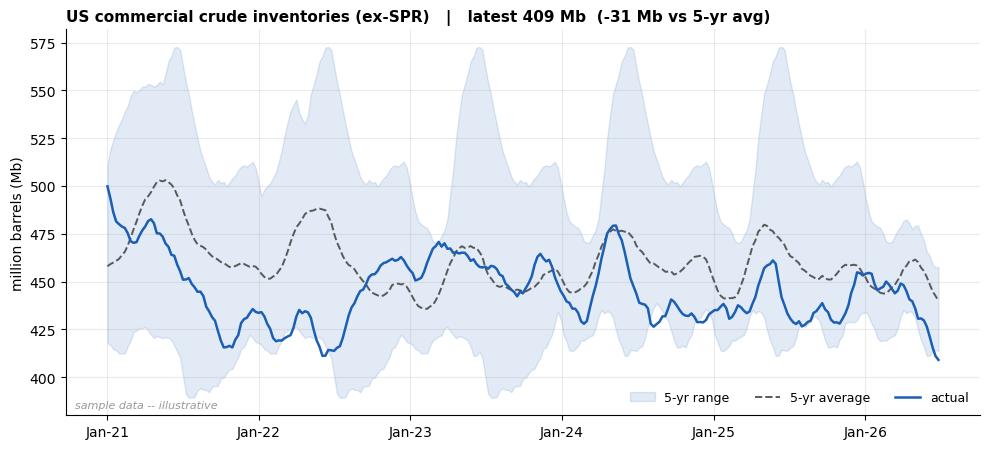

In [11]:
inv_chart(d["c_stk"], "US commercial crude inventories (ex-SPR)", "crude_inventories.png")

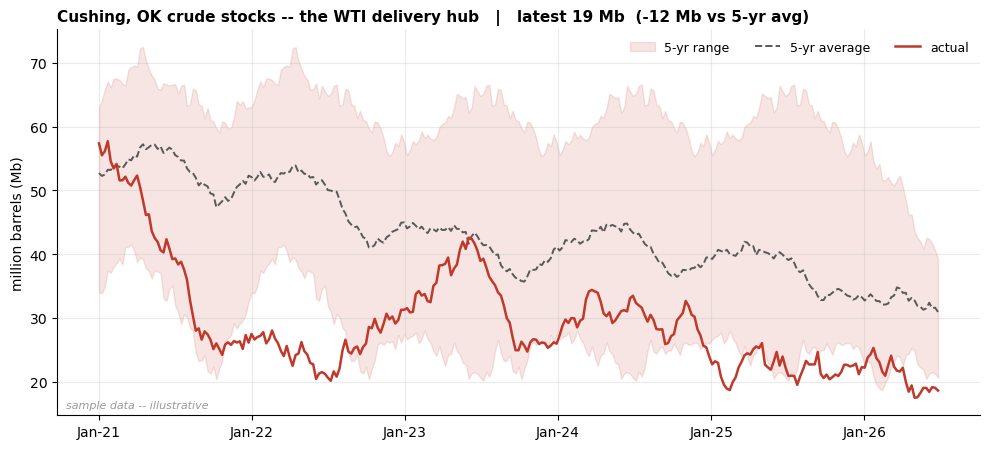

In [12]:
inv_chart(d["cush"], "Cushing, OK crude stocks -- the WTI delivery hub", "cushing.png",
          color="#c0392b")

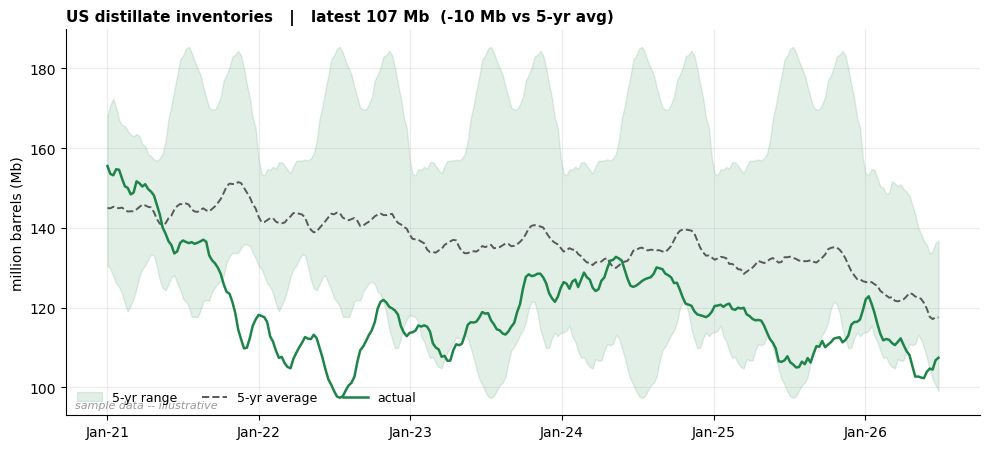

In [13]:
inv_chart(d["d_stk"], "US distillate inventories", "distillate_inventories.png",
          color="#1e8449")

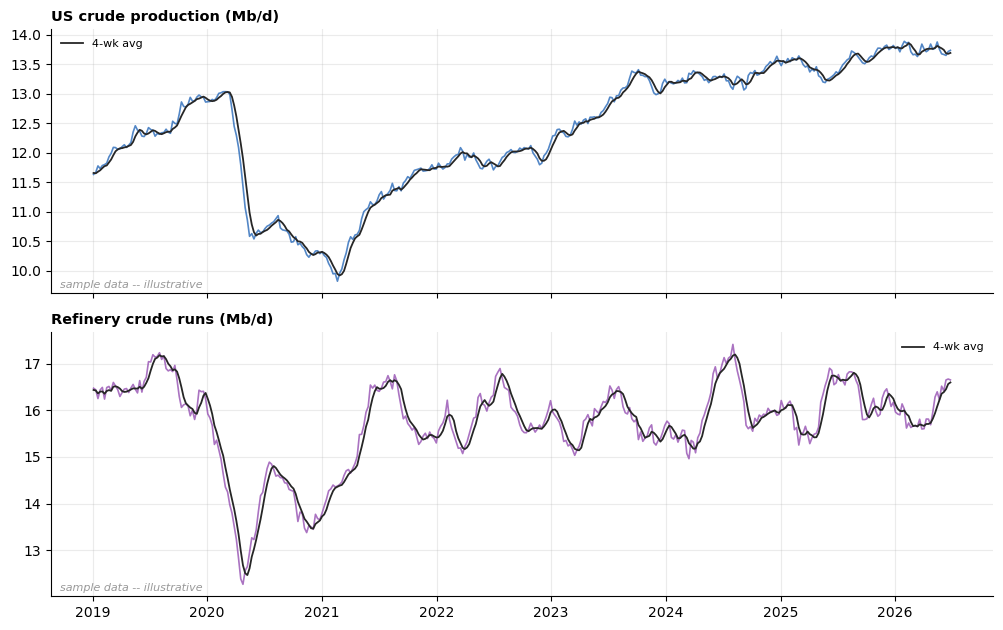

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, col, ttl, c in [(axes[0], "c_prod", "US crude production (Mb/d)", "#1a5fb4"),
                        (axes[1], "runs",   "Refinery crude runs (Mb/d)",  "#8e44ad")]:
    s = d[col][d.index >= "2019-01-01"]
    ax.plot(s.index, s, color=c, lw=1.2, alpha=0.75)
    ax.plot(s.index, d[col].rolling(4).mean().reindex(s.index), color="0.15", lw=1.3,
            label="4-wk avg")
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=10.5)
    ax.legend(frameon=False, fontsize=8)
    stamp(ax)
save_show(fig, "supply_side.png")

# Phase 2 · The balance sheet

Now the identity gets built explicitly, per commodity:

- **crude:** (field production + imports) − (refinery runs + exports)
- **distillate:** (refinery production + imports) − (product supplied + exports)

The weekly balance in Mb/d, multiplied by 7, gives the **implied** stock change; it is compared against the **actual** reported change. The gap between them is the *adjustment* — EIA's own reconciliation between surveyed flows and surveyed stock levels (the crude line was literally renamed from "unaccounted-for crude oil", and has run persistently positive since 2023). **It is a data-quality diagnostic, not a market signal.** When it blows out beyond its usual range, something in the inputs deserves a second look — that is where you dig.

In [15]:
# ── Phase 2: build the S/D balance sheet ─────────────────────────────────────
def build_balance(d):
    crude = pd.DataFrame({"supply_mbd": d.c_prod + d.c_imp,
                          "demand_mbd": d.runs + d.c_exp})
    dist = pd.DataFrame({"supply_mbd": d.d_prod + d.d_imp,
                         "demand_mbd": d.d_dem + d.d_exp})
    for b, stk in ((crude, d.c_stk), (dist, d.d_stk)):
        b["balance_mbd"]  = b.supply_mbd - b.demand_mbd
        b["implied_dstk"] = b.balance_mbd * 7.0        # Mb per week  (flows x 7)
        b["actual_dstk"]  = stk.diff()
        b["adjustment"]   = b.actual_dstk - b.implied_dstk   # EIA reconciliation proxy
    return crude, dist

bal_c, bal_d = build_balance(d)
print("Balance columns:", list(bal_c.columns))
print(f"Avg abs adjustment, last 52 wks -- crude: {bal_c.adjustment.tail(52).abs().mean():.1f} Mb/wk, "
      f"distillate: {bal_d.adjustment.tail(52).abs().mean():.1f} Mb/wk")

Balance columns: ['supply_mbd', 'demand_mbd', 'balance_mbd', 'implied_dstk', 'actual_dstk', 'adjustment']
Avg abs adjustment, last 52 wks -- crude: 3.6 Mb/wk, distillate: 1.3 Mb/wk


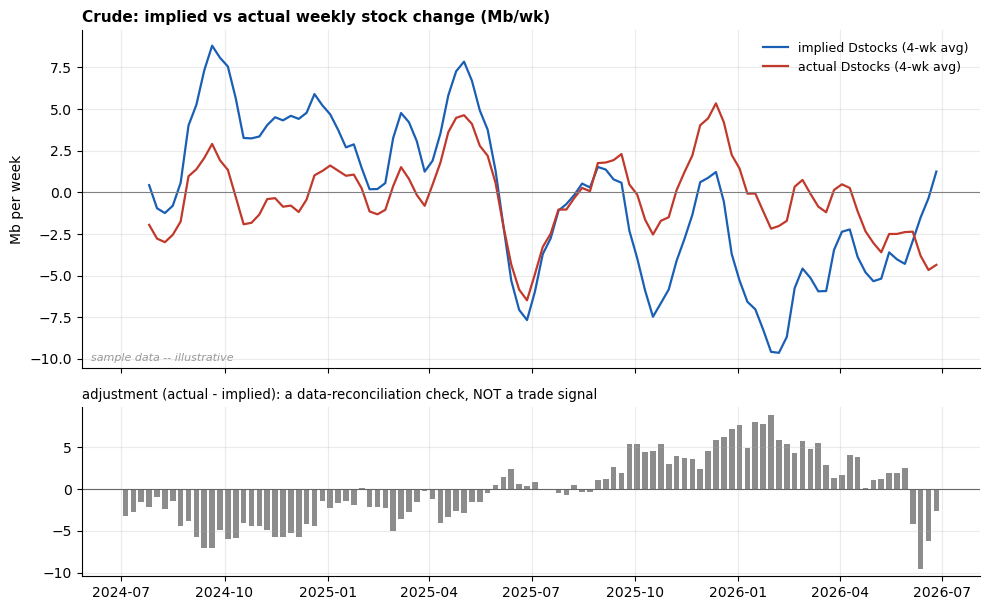

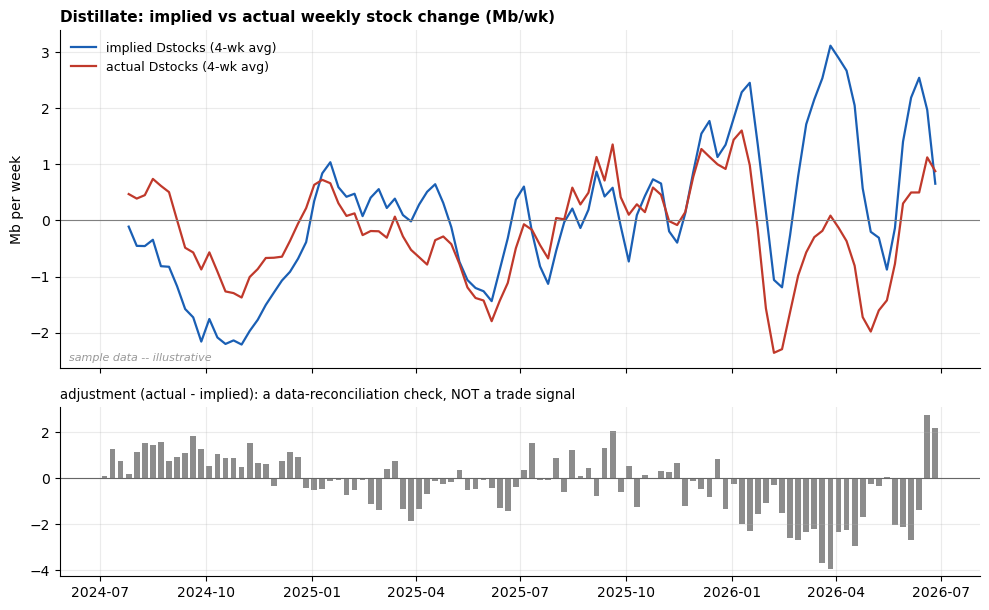

In [16]:
def balance_chart(b, name, fname):
    w = b[b.index >= "2024-07-01"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(w.index, w.implied_dstk.rolling(4).mean(), color="#1a5fb4", lw=1.6,
                 label="implied Dstocks (4-wk avg)")
    axes[0].plot(w.index, w.actual_dstk.rolling(4).mean(), color="#c0392b", lw=1.6,
                 label="actual Dstocks (4-wk avg)")
    axes[0].axhline(0, color="0.5", lw=0.8)
    axes[0].set_title(f"{name}: implied vs actual weekly stock change (Mb/wk)",
                      loc="left", fontweight="bold", fontsize=11)
    axes[0].set_ylabel("Mb per week")
    axes[0].legend(frameon=False, fontsize=9)
    axes[1].bar(w.index, w.adjustment, width=5, color="0.55")
    axes[1].axhline(0, color="0.4", lw=0.8)
    axes[1].set_title("adjustment (actual - implied): a data-reconciliation check, NOT a trade signal",
                      loc="left", fontsize=9.5)
    stamp(axes[0])
    save_show(fig, fname)

balance_chart(bal_c, "Crude", "balance_crude.png")
balance_chart(bal_d, "Distillate", "balance_distillate.png")

In [17]:
def latest_balance_table(d, bal_c, bal_d):
    i = d.index[-1]
    rows = {
        ("supply",  "Production"):                       (d.c_prod.loc[i], d.d_prod.loc[i]),
        ("supply",  "+ Imports"):                        (d.c_imp.loc[i],  d.d_imp.loc[i]),
        ("supply",  "= Total supply (Mb/d)"):            (bal_c.supply_mbd.loc[i], bal_d.supply_mbd.loc[i]),
        ("demand",  "Refinery runs / Product supplied"): (d.runs.loc[i],   d.d_dem.loc[i]),
        ("demand",  "+ Exports"):                        (d.c_exp.loc[i],  d.d_exp.loc[i]),
        ("demand",  "= Total demand (Mb/d)"):            (bal_c.demand_mbd.loc[i], bal_d.demand_mbd.loc[i]),
        ("balance", "Net balance (Mb/d)"):               (bal_c.balance_mbd.loc[i], bal_d.balance_mbd.loc[i]),
        ("balance", "Implied Dstocks (Mb/wk)"):          (bal_c.implied_dstk.loc[i], bal_d.implied_dstk.loc[i]),
        ("balance", "Actual Dstocks (Mb/wk)"):           (bal_c.actual_dstk.loc[i],  bal_d.actual_dstk.loc[i]),
        ("balance", "Adjustment (Mb/wk)"):               (bal_c.adjustment.loc[i],   bal_d.adjustment.loc[i]),
    }
    t = pd.DataFrame(rows, index=["crude", "distillate"]).T
    print(f"Weekly balance sheet -- week ending {i.date()}")
    return t.round(2)

latest_balance_table(d, bal_c, bal_d)

Weekly balance sheet -- week ending 2026-06-26


crude  distillate
supply  Production                        13.73        5.48
        + Imports                          5.99        0.02
        = Total supply (Mb/d)             19.72        5.50
demand  Refinery runs / Product supplied  16.65        4.03
        + Exports                          2.98        1.69
        = Total demand (Mb/d)             19.63        5.72
balance Net balance (Mb/d)                 0.09       -0.22
        Implied Dstocks (Mb/wk)            0.60       -1.55
        Actual Dstocks (Mb/wk)            -2.01        0.63
        Adjustment (Mb/wk)                -2.61        2.18

# Phase 3 · Seasonal analysis — the core output

This is the number a desk actually trades off: **how many barrels above or below normal, and which way is it moving?** The deviation series below is the model's central signal; the snapshot table condenses the entire market state into three rows.

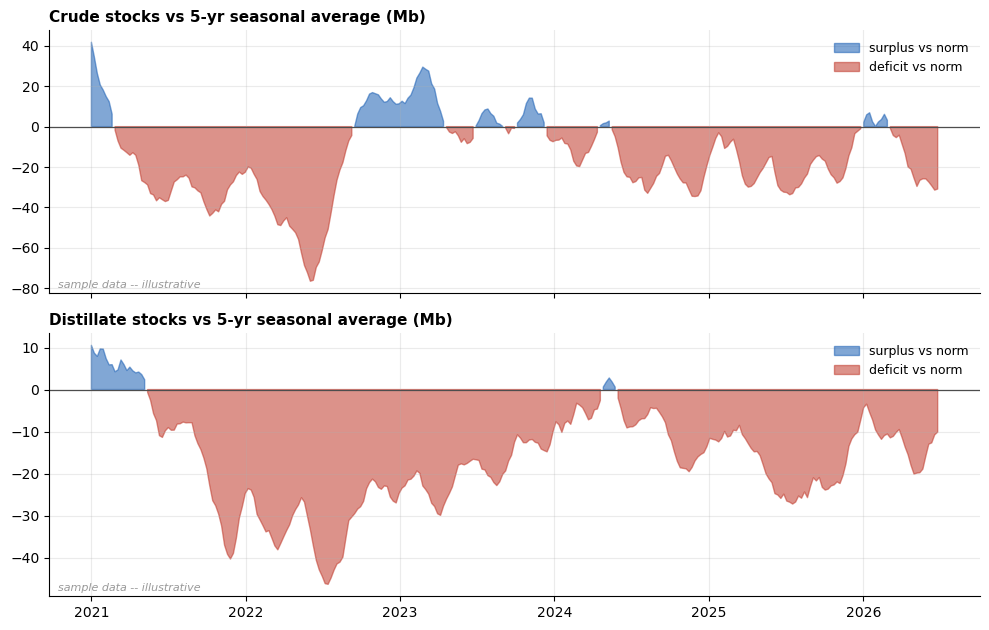

In [18]:
# ── Phase 3: inventory deviation vs the 5-yr seasonal norm (the core signal) ─
def deviation(s):
    avg, lo, hi = seasonal_series(s)
    dev = s - avg
    return dev, dev / avg * 100.0, (s - lo) / (hi - lo)

c_dev, c_devpct, c_pos = deviation(d.c_stk)
u_dev, u_devpct, u_pos = deviation(d.cush)
t_dev, t_devpct, t_pos = deviation(d.d_stk)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)
for ax, dev, ttl in [(axes[0], c_dev, "Crude stocks vs 5-yr seasonal average (Mb)"),
                     (axes[1], t_dev, "Distillate stocks vs 5-yr seasonal average (Mb)")]:
    w = dev[dev.index >= "2021-01-01"]
    ax.fill_between(w.index, 0, w.to_numpy(), where=(w >= 0).to_numpy(),
                    color="#1a5fb4", alpha=0.55, label="surplus vs norm")
    ax.fill_between(w.index, 0, w.to_numpy(), where=(w < 0).to_numpy(),
                    color="#c0392b", alpha=0.55, label="deficit vs norm")
    ax.axhline(0, color="0.3", lw=0.9)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc="best")
    stamp(ax)
save_show(fig, "seasonal_deviation.png")

In [19]:
def snapshot(d):
    out = {}
    for label, s, dev, devpct, pos in [
            ("Crude (comm., ex-SPR)", d.c_stk, c_dev, c_devpct, c_pos),
            ("Cushing",               d.cush,  u_dev, u_devpct, u_pos),
            ("Distillate",            d.d_stk, t_dev, t_devpct, t_pos)]:
        out[label] = {
            "level (Mb)":           float(s.iloc[-1]),
            "5-yr avg (Mb)":        float(s.iloc[-1] - dev.iloc[-1]),
            "vs 5-yr avg (Mb)":     float(dev.iloc[-1]),
            "vs 5-yr avg (%)":      float(devpct.iloc[-1]),
            "pos in 5-yr range":    float(pos.iloc[-1]),   # <0 means BELOW the 5-yr low
            "WoW D (Mb)":           float(s.diff().iloc[-1]),
            "4-wk D (Mb)":          float(s.iloc[-1] - s.iloc[-5]),
            "vs yr-ago (Mb)":       float(s.iloc[-1] - s.iloc[-53]),
        }
    return pd.DataFrame(out).T

snap = snapshot(d)
print(f"Inventory snapshot -- week ending {d.index[-1].date()}")
snap.round(2)

Inventory snapshot -- week ending 2026-06-26


,level (Mb),5-yr avg (Mb),vs 5-yr avg (Mb),vs 5-yr avg (%),pos in 5-yr range,WoW D (Mb),4-wk D (Mb),vs yr-ago (Mb)
"Crude (comm., ex-SPR)",409.00,439.91,-30.91,-7.03,-0.11,-2.01,-17.40,-24.33
Cushing,18.63,30.94,-12.31,-39.78,-0.11,-0.42,-0.41,-3.63
Distillate,107.40,117.52,-10.12,-8.61,0.22,0.63,3.51,-0.36


# Phase 4 · Forward projection

The baseline method is deliberately transparent: each flow follows its **5-year seasonal path**, plus the current 4-week deviation from that path **decaying at 0.85 per week** (momentum fades back toward normal). Implied weekly changes are integrated forward from the last actual level, carrying the recent average adjustment; the uncertainty band grows with √h using the historical dispersion of weekly stock-change surprises. Simple and fully explainable — every assumption is visible, which is the point in an interview.

In [20]:
# ── Phase 4: forward projection engine ───────────────────────────────────────
FLOWS = ["c_prod", "c_imp", "c_exp", "runs", "d_prod", "d_imp", "d_exp", "d_dem"]

def forecast_flows(d, horizon=HORIZON_WEEKS, decay=0.85):
    """Baseline flow forecast: the 5-yr seasonal path, plus the current 4-week
    deviation from that path fading out at `decay` per week (momentum -> normal)."""
    fut = pd.date_range(d.index[-1] + pd.Timedelta(weeks=1), periods=horizon, freq="W-FRI")
    fc = pd.DataFrame(index=fut)
    for c in FLOWS:
        sea_fut, _, _ = seasonal_series(d[c], fut)
        sea_now, _, _ = seasonal_series(d[c], d.index[-4:])
        dev = float(d[c].iloc[-4:].mean() - sea_now.mean())
        fc[c] = sea_fut.to_numpy() + dev * (decay ** np.arange(1, horizon + 1))
    return fc

def project(d, fc, adj_carry=True):
    """Integrate implied weekly changes forward from the last actual level.
    The recent average adjustment is carried (crude's is persistently positive)."""
    adj_c = float(bal_c.adjustment.tail(8).mean()) if adj_carry else 0.0
    adj_t = float(bal_d.adjustment.tail(8).mean()) if adj_carry else 0.0
    imp_c = (fc.c_prod + fc.c_imp - fc.runs - fc.c_exp) * 7.0 + adj_c
    imp_t = (fc.d_prod + fc.d_imp - fc.d_dem - fc.d_exp) * 7.0 + adj_t
    path_c = float(d.c_stk.iloc[-1]) + imp_c.cumsum()
    path_t = float(d.d_stk.iloc[-1]) + imp_t.cumsum()
    # uncertainty band: sd of weekly stock-change surprises, growing with sqrt(h)
    sd_c = float((d.c_stk.diff() - seasonal_series(d.c_stk.diff())[0]).tail(156).std())
    sd_t = float((d.d_stk.diff() - seasonal_series(d.d_stk.diff())[0]).tail(156).std())
    h = np.sqrt(np.arange(1, len(fc) + 1))
    return dict(fut=fc.index, crude=path_c, dist=path_t,
                band_c=1.28 * sd_c * h, band_t=1.28 * sd_t * h, flows=fc)

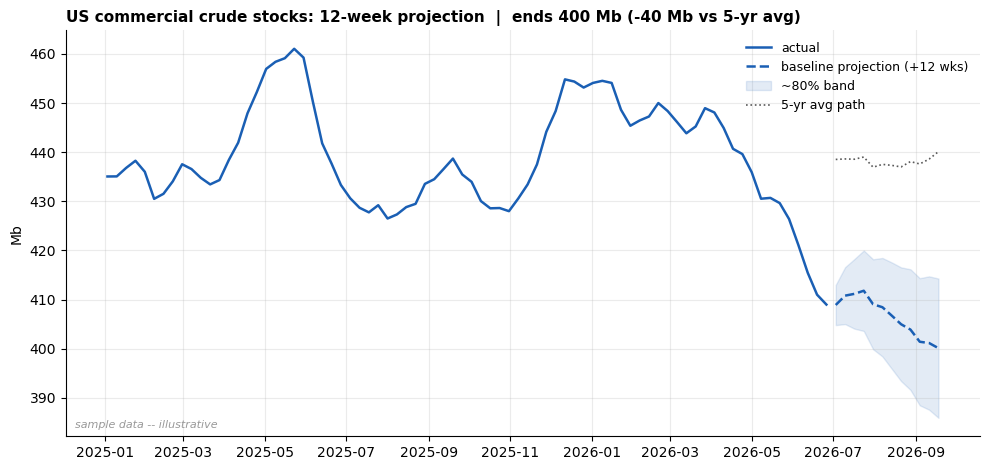

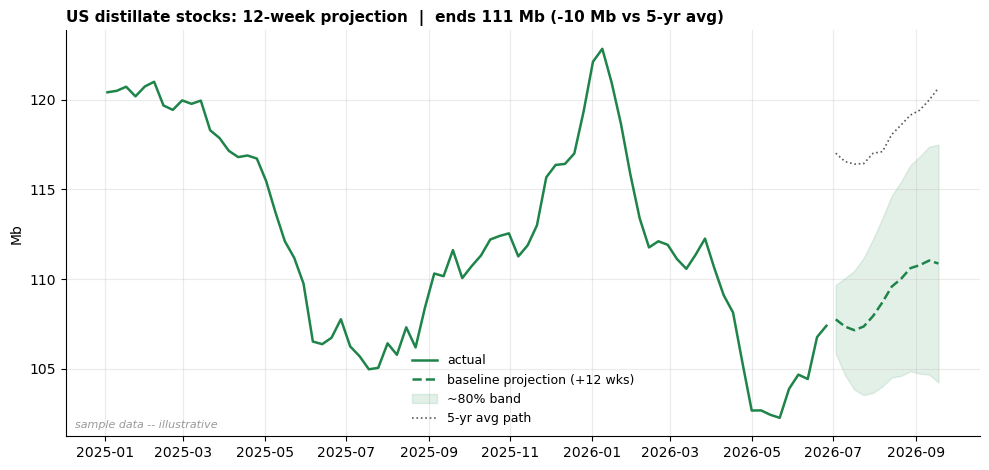

In [21]:
fc_base = forecast_flows(d)
proj = project(d, fc_base)

def projection_chart(hist, path, band, name, color, fname):
    avg_f, _, _ = seasonal_series(hist, path.index)
    w = hist[hist.index >= "2025-01-01"]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(w.index, w, color=color, lw=1.8, label="actual")
    ax.plot(path.index, path, color=color, lw=1.8, ls="--",
            label=f"baseline projection (+{len(path)} wks)")
    ax.fill_between(path.index, (path - band).to_numpy(), (path + band).to_numpy(),
                    color=color, alpha=0.12, label="~80% band")
    ax.plot(path.index, avg_f, color="0.35", lw=1.2, ls=":", label="5-yr avg path")
    enddev = float(path.iloc[-1] - avg_f.iloc[-1])
    ax.set_title(f"{name}: {len(path)}-week projection  |  ends {path.iloc[-1]:,.0f} Mb "
                 f"({enddev:+,.0f} Mb vs 5-yr avg)", loc="left", fontweight="bold", fontsize=11)
    ax.set_ylabel("Mb")
    ax.legend(frameon=False, fontsize=9, loc="best")
    stamp(ax)
    save_show(fig, fname)
    return enddev

end_dev_c = projection_chart(d.c_stk, proj["crude"], proj["band_c"],
                             "US commercial crude stocks", "#1a5fb4", "projection_crude.png")
end_dev_t = projection_chart(d.d_stk, proj["dist"], proj["band_t"],
                             "US distillate stocks", "#1e8449", "projection_distillate.png")

## What-if scenario tool

`run_scenario()` shocks any combination of flows for a chosen number of weeks, then reverts to baseline. A refinery-run shock automatically propagates to distillate output through the observed distillate yield (≈30% of crude runs) — cut runs and you *build* crude but *draw* diesel. The first example is the spec's: **refinery runs −5% for 4 weeks** (a hurricane / outage profile).

In [22]:
# ── What-if scenario tool ────────────────────────────────────────────────────
DIST_YIELD = float((d.d_prod / d.runs).tail(52).mean())   # distillate yield on runs (~0.30)

def run_scenario(d, label, weeks_shocked=4, runs_pct=0.0, c_prod_delta=0.0,
                 c_imp_delta=0.0, c_exp_delta=0.0, d_dem_pct=0.0, d_exp_delta=0.0,
                 horizon=HORIZON_WEEKS):
    """Apply shocks to the baseline flow forecast for the first `weeks_shocked`
    weeks, then revert. pct args are % changes; delta args are Mb/d add-ons.
    A refinery-run cut automatically cuts distillate output via DIST_YIELD."""
    base = forecast_flows(d, horizon)
    fc = base.copy()
    m = fc.index[np.arange(horizon) < weeks_shocked]
    d_runs = base.loc[m, "runs"] * (runs_pct / 100.0)
    fc.loc[m, "runs"]   = base.loc[m, "runs"] + d_runs
    fc.loc[m, "d_prod"] = base.loc[m, "d_prod"] + d_runs * DIST_YIELD
    fc.loc[m, "c_prod"] = base.loc[m, "c_prod"] + c_prod_delta
    fc.loc[m, "c_imp"]  = base.loc[m, "c_imp"]  + c_imp_delta
    fc.loc[m, "c_exp"]  = base.loc[m, "c_exp"]  + c_exp_delta
    fc.loc[m, "d_dem"]  = base.loc[m, "d_dem"] * (1 + d_dem_pct / 100.0)
    fc.loc[m, "d_exp"]  = base.loc[m, "d_exp"]  + d_exp_delta
    return dict(label=label, base=project(d, base), scen=project(d, fc))

def scenario_report(sc):
    bl, sn = sc["base"], sc["scen"]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, key, name, color, hist in [(axes[0], "crude", "Crude stocks", "#1a5fb4", d.c_stk),
                                       (axes[1], "dist", "Distillate stocks", "#1e8449", d.d_stk)]:
        w = hist[hist.index >= "2026-01-01"]
        ax.plot(w.index, w, color="0.4", lw=1.3, label="actual")
        ax.plot(bl["fut"], bl[key], color=color, lw=1.6, ls="--", label="baseline")
        ax.plot(sn["fut"], sn[key], color="#c0392b", lw=1.8, label=sc["label"])
        ax.set_title(name, loc="left", fontweight="bold", fontsize=10.5)
        ax.legend(frameon=False, fontsize=8)
        stamp(ax)
    save_show(fig, f"scenario_{sc['label'].replace(' ', '_').replace('%','pct')}.png")
    t = pd.DataFrame({
        "baseline end (Mb)":  [float(bl["crude"].iloc[-1]), float(bl["dist"].iloc[-1])],
        "scenario end (Mb)":  [float(sn["crude"].iloc[-1]), float(sn["dist"].iloc[-1])],
    }, index=["crude", "distillate"])
    t["impact vs baseline (Mb)"] = t["scenario end (Mb)"] - t["baseline end (Mb)"]
    print(f"Scenario: {sc['label']}  --  end-of-horizon inventories ({HORIZON_WEEKS} wks out)")
    return t.round(1)

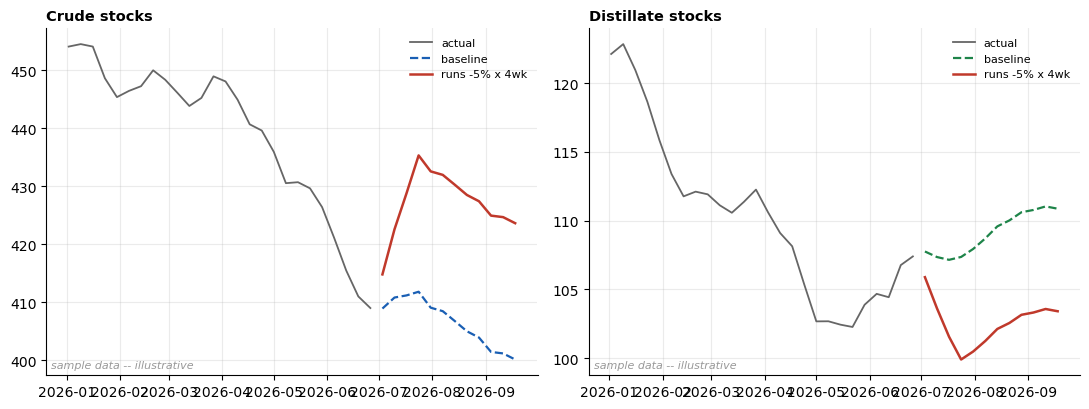

Scenario: runs -5% x 4wk  --  end-of-horizon inventories (12 wks out)


,baseline end (Mb),scenario end (Mb),impact vs baseline (Mb)
crude,400.10,423.60,23.50
distillate,110.90,103.40,-7.50


In [23]:
# The spec's example: refinery runs drop 5% for 4 weeks (hurricane / outage).
sc1 = run_scenario(d, "runs -5% x 4wk", weeks_shocked=4, runs_pct=-5.0)
scenario_report(sc1)

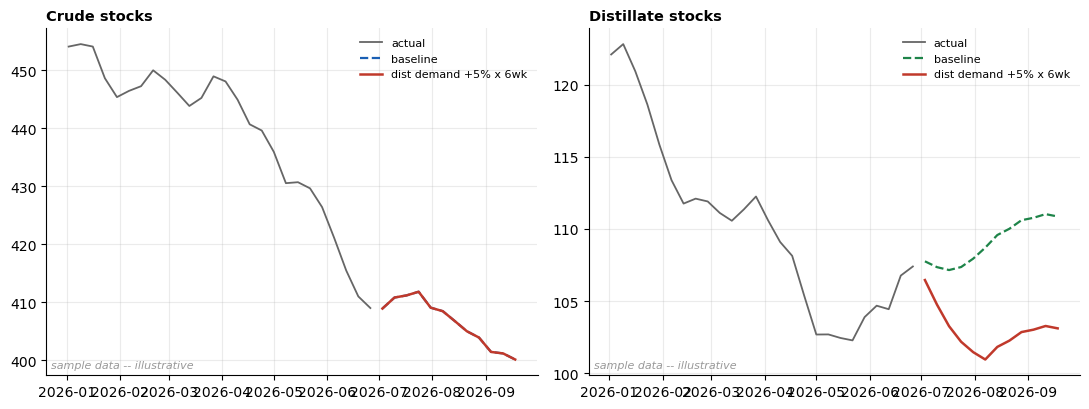

Scenario: dist demand +5% x 6wk  --  end-of-horizon inventories (12 wks out)


,baseline end (Mb),scenario end (Mb),impact vs baseline (Mb)
crude,400.10,400.10,0.00
distillate,110.90,103.10,-7.80


In [24]:
# A second example: a cold-snap style distillate demand pop, +5% for 6 weeks.
sc2 = run_scenario(d, "dist demand +5% x 6wk", weeks_shocked=6, d_dem_pct=5.0)
scenario_report(sc2)

# Extension build — regional layer · signal backtest · PADD map

Three additions ride on the framework above, in build-priority order: **(1)** a
10-year backtest of the model's core claim (inventory deviation leads price),
**(2)** a targeted PADD layer (PADD 1 / PADD 3 distillate — the NY Harbor crack
story and the Gulf Coast supply engine), **(3)** a PADD choropleth map. The
notebook sections run PADD → backtest → map because the backtest borrows the
regional series for a bonus study; the *build* priority is backtest first.

### ⚠️ VERIFY LOCALLY — 7 new EIA series IDs (best guesses)

This build environment cannot reach `api.eia.gov`, so the seven new series IDs
below are **best guesses verified against documentation only**. Each must be
confirmed on the live API (the fetch layer uses the full v1 format
`PET.{code}.W` — bare codes fail on the `seriesid` compatibility route).
A wrong ID does **not** crash the run: the fetcher prints exactly which full ID
failed and the dependent sections switch off gracefully.

| Purpose | Bare code | Full v1 identifier used | Unit |
|---|---|---|---|
| WTI Cushing spot (weekly) | `RWTC` | `PET.RWTC.W` | $/bbl |
| NY Harbor ULSD spot (weekly) | `EER_EPD2DXL0_PF4_Y35NY_DPG` | `PET.EER_EPD2DXL0_PF4_Y35NY_DPG.W` | $/gal |
| PADD 1 distillate stocks | `WDISTP11` | `PET.WDISTP11.W` | Mb |
| PADD 2 distillate stocks | `WDISTP21` | `PET.WDISTP21.W` | Mb |
| PADD 3 distillate stocks | `WDISTP31` | `PET.WDISTP31.W` | Mb |
| PADD 4 distillate stocks | `WDISTP41` | `PET.WDISTP41.W` | Mb |
| PADD 5 distillate stocks | `WDISTP51` | `PET.WDISTP51.W` | Mb |

If ULSD history proves too short for the 10-year sample on the live pull, the
documented fallback is the NY Harbor No. 2 heating oil spot series
(`PET.EER_EPD2F_PF4_Y35NY_DPG.W`) — see `DECISIONS.md` #14.

**Units discipline for the new columns:** stocks stay Mb; the two price series
are **$/bbl and $/gal** — prices are not volumes, and the ×7 Mb/d→Mb weekly
conversion must never touch them.

# Feature 2 · The regional layer — PADD 1 & PADD 3 distillate

National stocks answer *"is the US tight?"* — but the futures contract that
prices distillate tightness (NY Harbor ULSD) delivers into **PADD 1**, so PADD 1
tightness *is* the crack story. **PADD 3** holds the refining center that
supplies it. The spread between the two — how much tighter the East Coast is
than the Gulf — proxies the economics of shipping product east on the Colonial
pipeline system.

Two rules keep this layer honest:

1. **PADDs are a view layer, not new balance rows.** The five PADD series are
   components of the national total (`WDISTUS1`) and already live inside every
   national number above. Adding them to the balance would double-count — the
   QA cell checks they sum to the US total.
2. **One seasonal implementation.** Each PADD's 5-yr norm and deviation come
   from the *same* `seasonal_series()` / `deviation()` functions as the
   national series — no forked second implementation to drift out of sync.

In [25]:
# ── PADD seasonal deviations (reusing the existing seasonal framework) ───────
PADDS = {   # number -> (name, short column)
    1: ("East Coast", "d_stk_p1"), 2: ("Midwest", "d_stk_p2"),
    3: ("Gulf Coast", "d_stk_p3"), 4: ("Rockies", "d_stk_p4"),
    5: ("West Coast", "d_stk_p5"),
}
PADD_COLS = [col for _, col in PADDS.values()]
PADD_OK = HAVE(*PADD_COLS)

# defaults so Phase 5 / the PDF never crash if this tier lacks the PADD series
REGIONAL_LINE = ("Regional layer unavailable in this data tier -- verify the WDISTP*1 "
                 "series IDs against the live API and refresh the cache.")
padd, padd_tbl, p1p3_rel = {}, None, None

if not PADD_OK:
    print("! PADD series missing from this data tier -- regional layer skipped.")
else:
    # NOTE: PADDs are COMPONENTS of the national total -- a view layer. They are
    # never added on top of the national balance (that would double-count).
    for num, (name, col) in PADDS.items():
        dev, devpct, pos = deviation(d[col])        # same functions as the national signal
        padd[num] = dict(name=name, col=col, s=d[col], dev=dev, devpct=devpct,
                         pos=pos, avg=d[col] - dev)

    padd_tbl = pd.DataFrame({
        f"PADD {n} ({p['name']})": {
            "level (Mb)":        float(p["s"].iloc[-1]),
            "5-yr norm (Mb)":    float(p["avg"].iloc[-1]),
            "vs norm (Mb)":      float(p["dev"].iloc[-1]),
            "vs norm (%)":       float(p["devpct"].iloc[-1]),
            "pos in 5-yr range": float(p["pos"].iloc[-1]),
            "WoW D (Mb)":        float(p["s"].diff().iloc[-1]),
        } for n, p in padd.items()
    }).T

    # P1 − P3 relative tightness (pts of % deviation): negative = East Coast
    # tighter than the Gulf = incentive to ship product east (Colonial arb proxy)
    p1p3_rel = padd[1]["devpct"] - padd[3]["devpct"]

    print(f"PADD distillate snapshot -- week ending {d.index[-1].date()}   "
          f"(components sum to US total: "
          f"{float(d[PADD_COLS].sum(axis=1).iloc[-1]):,.1f} vs {float(d.d_stk.iloc[-1]):,.1f} Mb)")
    print(f"P1-P3 relative tightness: {float(p1p3_rel.iloc[-1]):+.1f} pts")
    display(padd_tbl.round(2))

PADD distillate snapshot -- week ending 2026-06-26   (components sum to US total: 107.4 vs 107.4 Mb)
P1-P3 relative tightness: -4.9 pts


,level (Mb),5-yr norm (Mb),vs norm (Mb),vs norm (%),pos in 5-yr range,WoW D (Mb)
PADD 1 (East Coast),29.29,32.38,-3.10,-9.56,0.22,0.48
PADD 2 (Midwest),27.26,31.20,-3.95,-12.65,0.11,0.41
PADD 3 (Gulf Coast),37.33,39.15,-1.83,-4.66,0.32,-0.54
PADD 4 (Rockies),3.46,3.80,-0.34,-8.95,0.09,0.09
PADD 5 (West Coast),10.07,10.99,-0.91,-8.32,0.26,0.20


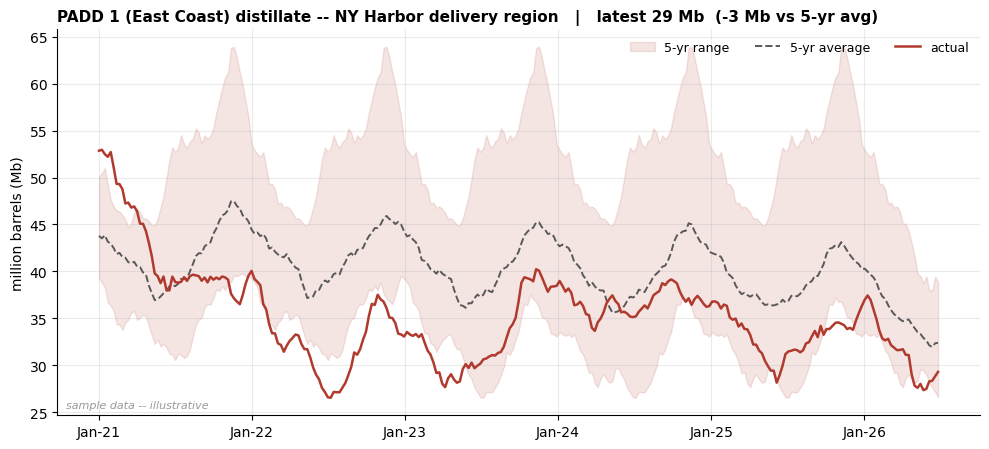

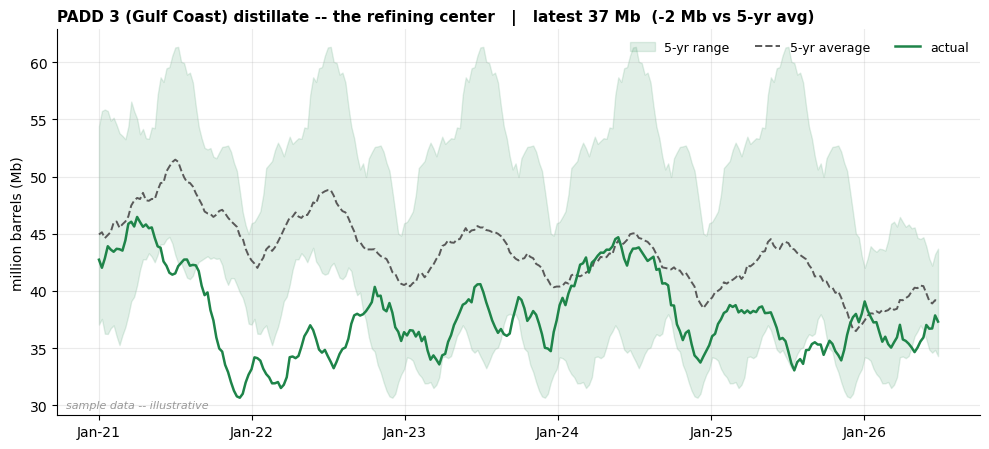

In [26]:
# ── PADD 1 & PADD 3 vs their own 5-yr seasonal bands ─────────────────────────
# Same chart function as the national inventory charts -- identical visual style.
if PADD_OK:
    inv_chart(d.d_stk_p1, "PADD 1 (East Coast) distillate -- NY Harbor delivery region",
              "padd1_distillate.png", color="#b03a2e")
    inv_chart(d.d_stk_p3, "PADD 3 (Gulf Coast) distillate -- the refining center",
              "padd3_distillate.png", color="#1e8449")

In [27]:
# ── The regional market-view sentence (feeds Phase 5 + the PDF) ──────────────
if PADD_OK:
    _p1 = padd[1]
    _lvl, _dev = float(_p1["s"].iloc[-1]), float(_p1["dev"].iloc[-1])
    _pct, _rel = float(_p1["devpct"].iloc[-1]), float(p1p3_rel.iloc[-1])
    # same ±4% TIGHT / BALANCED / LOOSE bands as Phase 5's classify()
    _p1_read = ("tight, constructive for ULSD cracks" if _pct < -4
                else "loose, a headwind for ULSD cracks" if _pct > 4
                else "near normal -- neutral for ULSD cracks")
    REGIONAL_LINE = (
        f"PADD 1 distillate {_lvl:,.1f} Mb, {abs(_dev):,.1f} Mb ({abs(_pct):.0f}%) "
        f"{'below' if _dev < 0 else 'above'} its 5-yr norm -- NY Harbor {_p1_read}; "
        f"P1-P3 relative tightness {_rel:+.1f} pts "
        f"{'implies incentive to ship product east (Colonial-arb pull)' if _rel < 0 else 'implies the East Coast is well supplied vs the Gulf'}.")
print(REGIONAL_LINE)

PADD 1 distillate 29.3 Mb, 3.1 Mb (10%) below its 5-yr norm -- NY Harbor tight, constructive for ULSD cracks; P1-P3 relative tightness -4.9 pts implies incentive to ship product east (Colonial-arb pull).


# Feature 1 · Signal backtest — does the deviation signal actually lead prices?

Everything above assumes the model's core claim: **inventory deviation vs the
5-yr seasonal norm precedes price and spread moves.** This section tests that
claim over the last 10 years and reports the honest result either way — a clean
negative result is a valid outcome, and nothing here is tuned until it "works."

**Setup.** Two weekly price series join the dataset: WTI Cushing spot ($/bbl)
and NY Harbor ULSD spot ($/gal). The **diesel crack** = ULSD × 42 − WTI, in
$/bbl (42 gallons per barrel — the same class of unit trap as Mb vs Mb/d). Two
studies:

- **(a)** distillate stocks %-deviation → forward *diesel crack* change ($/bbl)
- **(b)** crude stocks %-deviation → forward *WTI flat price* change ($/bbl)

The signals are exactly the `%`-deviations Phase 3 already computes — % rather
than Mb because a 10 Mb deficit meant something different in 2016 than it does
today; % is scale-free across the decade (`DECISIONS.md` #15).

**Publication lag.** WPSR data for the week ending Friday *t* is published the
following **Wednesday**. The signal is therefore lagged one week: deviation of
week *t* is paired with the price change from week *t+1* to *t+1+h*, h ∈ {4, 8}
weeks (an assertion locks the index arithmetic in). One residual caveat the
assertion *cannot* catch: these are weekly-**average** price series, and the
week-(t+1) average includes Monday–Wednesday-morning prices that predate the
release — so any announcement-day pop is partially booked in the entry leg,
a bias that leans *pro-thesis*. The summary therefore also reports a
conservative variant entering at week *t+2* (the first fully post-release
average).

**Honest-statistics caveats, stated up front:** forward windows overlap
(consecutive weeks share h−1 weeks of the same move), so the *effective*
sample is roughly n/h and naive significance is overstated; results are also
regime-dependent (a rolling-correlation chart below shows how much). With
`START_DATE = 2015`, the 5-yr seasonal warm-up means deviations only exist from
2020 — to get the full 10-year window on live data, set `START_DATE`
to 2009 before pulling (see the run-locally checklist).

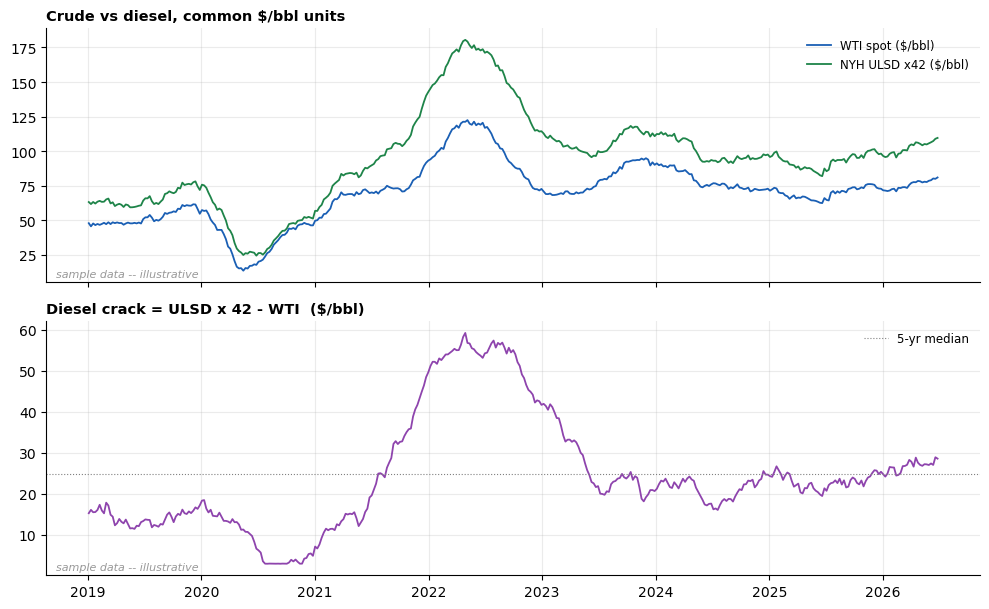

Prices: WTI $80.97/bbl, NYH ULSD $2.609/gal, diesel crack $28.61/bbl (+1.55 $/bbl over 4 wks).


In [28]:
# ── Price layer: WTI, ULSD and the diesel crack ──────────────────────────────
PRICES_OK = HAVE("wti", "ulsd")
PRICE_LINE  = "Price layer unavailable in this data tier -- verify PET.RWTC.W / PET.EER_EPD2DXL0_PF4_Y35NY_DPG.W."
BT_HEADLINE = "Backtest unavailable in this data tier (price series missing)."
crack = None

if not PRICES_OK:
    print("! WTI / ULSD missing from this data tier -- backtest skipped.")
else:
    # UNITS: ULSD is $/GALLON, WTI is $/BARREL. 42 gal = 1 bbl, so ULSD converts
    # to $/bbl BEFORE differencing. Prices are never volumes: the x7 Mb/d->Mb
    # conversion must NEVER touch these columns.
    crack = d.ulsd * 42.0 - d.wti          # diesel crack, $/bbl
    crack.name = "diesel_crack"

    _w = d.index >= "2019-01-01"
    fig, axes = plt.subplots(2, 1, figsize=(10, 6.2), sharex=True)
    axes[0].plot(d.index[_w], d.wti[_w], color="#1a5fb4", lw=1.3, label="WTI spot ($/bbl)")
    axes[0].plot(d.index[_w], (d.ulsd * 42.0)[_w], color="#1e8449", lw=1.3,
                 label="NYH ULSD x42 ($/bbl)")
    axes[0].set_title("Crude vs diesel, common $/bbl units", loc="left",
                      fontweight="bold", fontsize=10.5)
    axes[0].legend(frameon=False, fontsize=8.5)
    axes[1].plot(d.index[_w], crack[_w], color="#8e44ad", lw=1.3)
    axes[1].axhline(float(crack.tail(260).median()), color="0.5", lw=0.8, ls=":",
                    label="5-yr median")
    axes[1].set_title("Diesel crack = ULSD x 42 - WTI  ($/bbl)", loc="left",
                      fontweight="bold", fontsize=10.5)
    axes[1].legend(frameon=False, fontsize=8.5)
    for ax in axes:
        stamp(ax)
    save_show(fig, "prices_crack.png")

    _c4 = float(crack.iloc[-1] - crack.iloc[-5])
    PRICE_LINE = (f"Prices: WTI ${float(d.wti.iloc[-1]):.2f}/bbl, NYH ULSD "
                  f"${float(d.ulsd.iloc[-1]):.3f}/gal, diesel crack "
                  f"${float(crack.iloc[-1]):.2f}/bbl ({_c4:+.2f} $/bbl over 4 wks).")
    print(PRICE_LINE)

In [29]:
# ── Backtest machinery: signal/return alignment with the publication lag ─────
BACKTEST_YEARS = 10          # evaluation window (uses whatever overlap exists)
BT_HORIZONS    = (4, 8)      # forward horizons, weeks
COVID_EXCL     = ("2020-03-01", "2021-02-28")   # robustness cut (DECISIONS #17)

def forward_change(price: pd.Series, h: int) -> pd.Series:
    """Forward change aligned WITHOUT index lookahead.

    WPSR data for the week ending Friday t is PUBLISHED the following Wednesday,
    so the earliest realistic action on the week-t signal is during week t+1.
    The week-t row is therefore paired with the change from t+1 to t+1+h:
        price[t+1+h] - price[t+1]   (shift(-(1+h)) - shift(-1))
    Residual caveat (see the markdown above): weekly-AVERAGE prices mean part
    of the week-(t+1) entry leg predates the Wednesday release."""
    return price.shift(-(1 + h)) - price.shift(-1)

def covid_overlap(idx, h: int):
    """True where the signal week OR its forward window [t+1, t+1+h] touches
    the COVID exclusion period. Filtering on the signal date alone would leave
    Jan/Feb-2020 signals whose forward windows contain the March crash inside
    the 'ex-COVID' sample -- the mask must be horizon-aware."""
    start = pd.Timestamp(COVID_EXCL[0]) - pd.Timedelta(weeks=1 + h)
    return (idx >= start) & (idx <= pd.Timestamp(COVID_EXCL[1]))

bt = None
BT_OK = False
BT_SUMMARY = "Backtest not run in this tier (price series unavailable)."
if PRICES_OK:
    bt = pd.DataFrame({
        "sig_dist":  t_devpct,     # Phase-3 distillate % deviation (the signal, %)
        "sig_crude": c_devpct,     # Phase-3 crude % deviation (the signal, %)
    })
    for h in BT_HORIZONS:
        bt[f"crack_fwd{h}"] = forward_change(crack, h)   # $/bbl
        bt[f"wti_fwd{h}"]   = forward_change(d.wti, h)   # $/bbl
    bt = bt.loc[bt.index >= bt.index.max() - pd.DateOffset(years=BACKTEST_YEARS)]

    # Alignment assertion on the NaN-free part of the price history: the h=4
    # forward change really spans positions +1 .. +5 (shift is positional).
    _cr = crack.dropna()
    if len(_cr) >= 30:
        _i = len(_cr) - 20
        assert np.isclose(forward_change(_cr, 4).iloc[_i], _cr.iloc[_i + 5] - _cr.iloc[_i + 1]), \
            "publication-lag alignment broken"

    _ov = bt[["sig_dist", "crack_fwd4"]].dropna()
    _n = int(len(_ov))
    BT_OK = _n >= 52
    if BT_OK:
        print(f"alignment check PASS  |  usable overlapping weeks (study a, h=4): {_n}   "
              f"signals {_ov.index.min().date()} -> {_ov.index.max().date()} "
              f"(each with a complete 4-wk forward window)")
    else:
        BT_SUMMARY = (f"Backtest suppressed: only {_n} overlapping signal/price weeks "
                      f"in this tier (needs 52+).")
        BT_HEADLINE = BT_SUMMARY
        print(f"! only {_n} usable weeks -- backtest suppressed for this tier.")

alignment check PASS  |  usable overlapping weeks (study a, h=4): 334   signals 2020-01-03 -> 2026-05-22 (each with a complete 4-wk forward window)


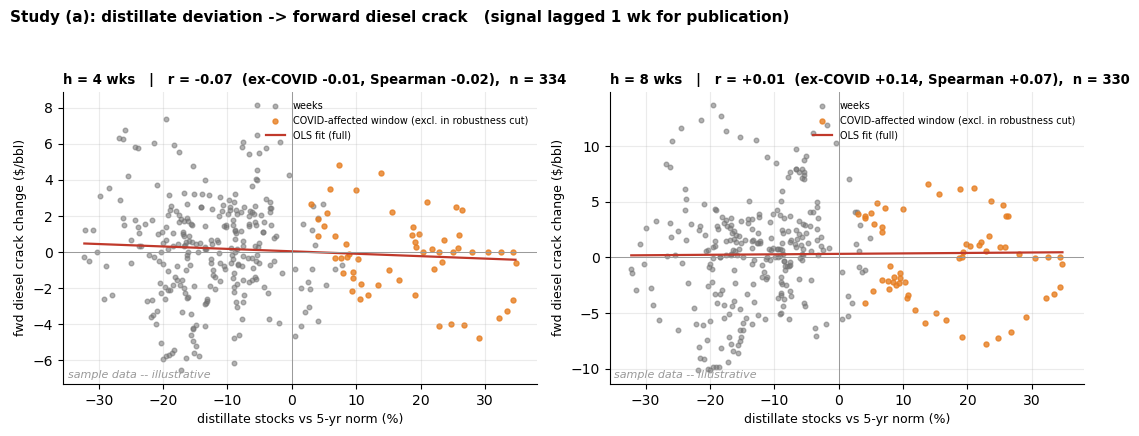

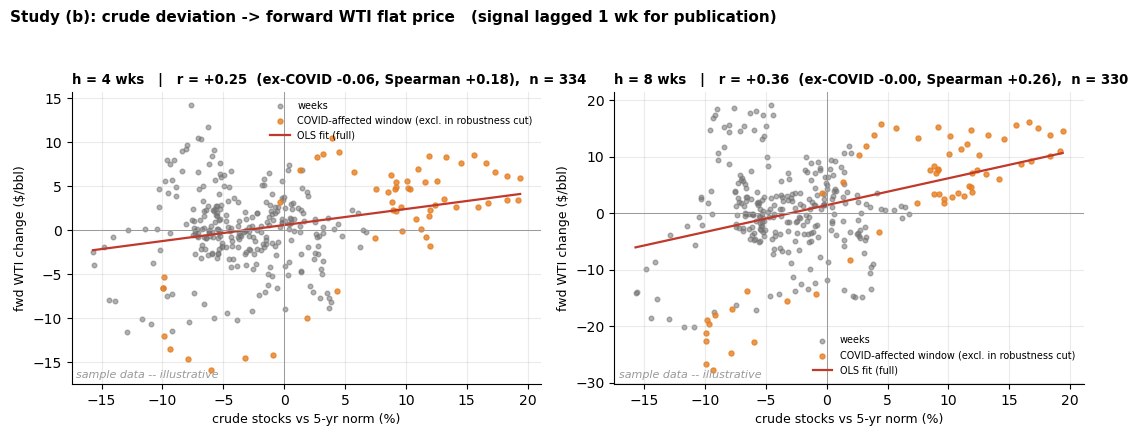

In [30]:
# ── Scatters: deviation % vs forward move, both studies x both horizons ──────
STUDIES = {
    "a": dict(sig="sig_dist",  fwd="crack_fwd", sig_lbl="distillate stocks vs 5-yr norm (%)",
              fwd_lbl="fwd diesel crack change ($/bbl)", fname="backtest_dist_crack.png",
              title="Study (a): distillate deviation -> forward diesel crack"),
    "b": dict(sig="sig_crude", fwd="wti_fwd",   sig_lbl="crude stocks vs 5-yr norm (%)",
              fwd_lbl="fwd WTI change ($/bbl)", fname="backtest_crude_wti.png",
              title="Study (b): crude deviation -> forward WTI flat price"),
}

def _pearson(x, y):  return float(np.corrcoef(x, y)[0, 1])
def _spearman(x, y): return float(np.corrcoef(x.rank(), y.rank())[0, 1])

if BT_OK:
    for st in STUDIES.values():
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
        for ax, h in zip(axes, BT_HORIZONS):
            sub = bt[[st["sig"], f"{st['fwd']}{h}"]].dropna()
            x, y = sub[st["sig"]], sub[f"{st['fwd']}{h}"]
            # horizon-aware: a point is COVID-affected if its FORWARD WINDOW
            # touches the exclusion period, not just its signal date
            nc = ~covid_overlap(sub.index, h)
            ax.scatter(x[nc], y[nc], s=11, color="0.45", alpha=0.55, label="weeks")
            ax.scatter(x[~nc], y[~nc], s=13, color="#e67e22", alpha=0.8,
                       label="COVID-affected window (excl. in robustness cut)")
            b1, b0 = np.polyfit(x, y, 1)
            xs = np.linspace(float(x.min()), float(x.max()), 50)
            ax.plot(xs, b0 + b1 * xs, color="#c0392b", lw=1.6, label="OLS fit (full)")
            r, rs = _pearson(x, y), _spearman(x, y)
            rx = _pearson(x[nc], y[nc])
            ax.set_title(f"h = {h} wks   |   r = {r:+.2f}  (ex-COVID {rx:+.2f}, "
                         f"Spearman {rs:+.2f}),  n = {len(sub)}",
                         loc="left", fontsize=9.5, fontweight="bold")
            ax.axhline(0, color="0.6", lw=0.7); ax.axvline(0, color="0.6", lw=0.7)
            ax.set_xlabel(st["sig_lbl"], fontsize=9)
            ax.set_ylabel(st["fwd_lbl"], fontsize=9)
            ax.legend(frameon=False, fontsize=7)
            stamp(ax)
        fig.suptitle(st["title"] + "   (signal lagged 1 wk for publication)",
                     x=0.01, ha="left", fontsize=11, fontweight="bold")
        fig.tight_layout(rect=[0, 0, 1, 0.94])
        fig.savefig(CHART_DIR / st["fname"], dpi=150, bbox_inches="tight")
        plt.show()

In [31]:
# ── Tercile analysis: tight / neutral / loose thirds of the signal ───────────
# Buckets are terciles of the signal WITHIN each evaluation sample, so "tight"
# means "the tightest third of the period" (relative, robust to level shifts).
# Hit rate = share of weeks where the forward move matched the signal's
# direction: tight -> move > 0, loose -> move < 0; undefined for neutral.
def study_stats(sig_col, fwd_prefix):
    rows, stats = {}, {}
    for cut in ["full", "ex-COVID"]:
        for h in BT_HORIZONS:
            sub = bt[[sig_col, f"{fwd_prefix}{h}"]].dropna()
            if cut == "ex-COVID":
                # horizon-aware exclusion: drop any row whose forward window
                # overlaps the COVID period (signal-date-only filtering leaks
                # the March-2020 crash into "ex-COVID" forward returns)
                sub = sub[~covid_overlap(sub.index, h)]
            if len(sub) < 30:
                continue
            q1, q2 = sub[sig_col].quantile([1 / 3, 2 / 3])
            bucket = pd.cut(sub[sig_col], [-np.inf, q1, q2, np.inf],
                            labels=["tight", "neutral", "loose"])
            x, y = sub[sig_col], sub[f"{fwd_prefix}{h}"]
            stats[(cut, h)] = dict(r=_pearson(x, y), rs=_spearman(x, y), n=len(sub))
            for b in ["tight", "neutral", "loose"]:
                m = y[bucket == b]
                hit = (float((m > 0).mean()) if b == "tight"
                       else float((m < 0).mean()) if b == "loose" else np.nan)
                rows[(cut, b, f"{h}w")] = dict(**{
                    "avg move ($/bbl)": float(m.mean()),
                    "median ($/bbl)":   float(m.median()),
                    "hit rate":         hit,
                    "n":                int(len(m))})
                stats[(cut, h, b)] = rows[(cut, b, f"{h}w")]
    tbl = (pd.DataFrame(rows).T
             .rename_axis(["sample", "bucket", "horizon"])
             .unstack("horizon").swaplevel(0, 1, axis=1).sort_index(axis=1)
             .reindex(["tight", "neutral", "loose"], level="bucket")
             .reindex(["full", "ex-COVID"], level="sample"))
    return tbl, stats

BT_STATS = {}
if BT_OK:
    for key, st in STUDIES.items():
        tbl, stats = study_stats(st["sig"], st["fwd"])
        BT_STATS[key] = stats
        print(f"\n{st['title']}  --  tercile table "
              f"(hit rate: tight->up / loose->down; overlap means effective n ~ n/h)")
        display(tbl.round(2))


Study (a): distillate deviation -> forward diesel crack  --  tercile table (hit rate: tight->up / loose->down; overlap means effective n ~ n/h)


horizon                        4w                                              8w                               
                 avg move ($/bbl) hit rate median ($/bbl)      n avg move ($/bbl) hit rate median ($/bbl)      n
sample   bucket                                                                                                 
full     tight               0.08     0.56           0.32 111.00            -0.57     0.54           0.23 110.00
         neutral             0.05      NaN           0.19 111.00             0.77      NaN           0.75 110.00
         loose               0.28     0.48           0.01 112.00             0.66     0.40           0.70 110.00
ex-COVID tight               0.17     0.56           0.32  93.00            -0.33     0.54           0.23  90.00
         neutral            -0.16      NaN           0.19  91.00            -0.13      NaN           0.64  89.00
         loose               0.56     0.45           0.37  93.00             1.66     0.34           1.25  90.00


Study (b): crude deviation -> forward WTI flat price  --  tercile table (hit rate: tight->up / loose->down; overlap means effective n ~ n/h)


horizon                        4w                                              8w                               
                 avg move ($/bbl) hit rate median ($/bbl)      n avg move ($/bbl) hit rate median ($/bbl)      n
sample   bucket                                                                                                 
full     tight              -0.10     0.51           0.08 111.00            -1.27     0.45          -0.18 110.00
         neutral            -0.32      NaN          -0.06 111.00             0.10      NaN           0.70 110.00
         loose               1.32     0.34           1.50 112.00             3.28     0.31           3.46 110.00
ex-COVID tight               0.74     0.56           0.19  93.00             0.98     0.52           0.96  90.00
         neutral            -0.26      NaN          -0.29  91.00            -0.12      NaN          -0.59  89.00
         loose              -0.35     0.44           0.52  93.00             0.09     0.43           1.08  90.00

Study (c): P1-P3 relative tightness (pts) -> forward diesel crack change
  h=4w: r = +0.33 (Spearman +0.35), n = 334  |  P1-tight-tercile avg -1.03 vs P1-loose +1.50 $/bbl
  h=8w: r = +0.44 (Spearman +0.46), n = 330  |  P1-tight-tercile avg -2.46 vs P1-loose +3.01 $/bbl


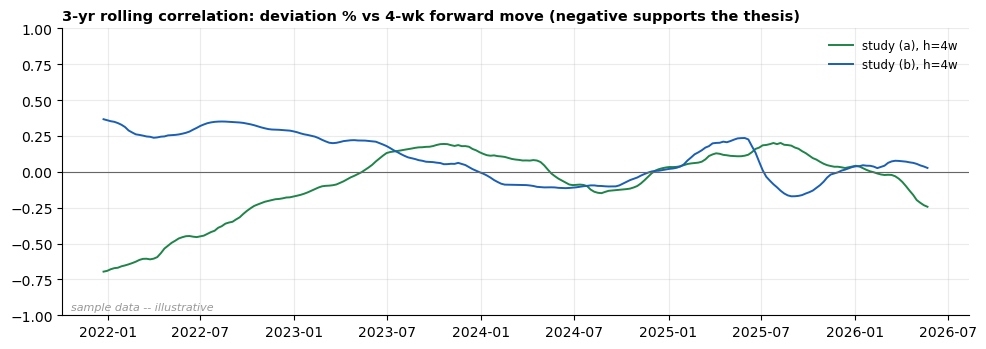

In [32]:
# ── Extension study (c) + signal stability (beyond the spec) ─────────────────
# (c) Does P1-P3 RELATIVE tightness (Feature 2) lead the crack better than the
#     national number? Same lag, same horizons -- reported compactly.
if BT_OK and PADD_OK:
    _rel = p1p3_rel.reindex(bt.index)
    print("Study (c): P1-P3 relative tightness (pts) -> forward diesel crack change")
    for h in BT_HORIZONS:
        sub = pd.concat([_rel, bt[f"crack_fwd{h}"]], axis=1).dropna()
        if len(sub) < 30:
            print(f"  h={h}w: insufficient overlap (n={len(sub)})"); continue
        x, y = sub.iloc[:, 0], sub.iloc[:, 1]
        q1, q2 = x.quantile([1 / 3, 2 / 3])
        tight, loose = y[x <= q1], y[x >= q2]
        print(f"  h={h}w: r = {_pearson(x, y):+.2f} (Spearman {_spearman(x, y):+.2f}), "
              f"n = {len(sub)}  |  P1-tight-tercile avg {float(tight.mean()):+.2f} vs "
              f"P1-loose {float(loose.mean()):+.2f} $/bbl")

# Signal stability: 3-yr rolling correlation. A signal that only worked in one
# regime is a different (and weaker) claim than one that works across regimes.
if BT_OK:
    fig, ax = plt.subplots(figsize=(10, 3.6))
    for key, st, colr in [("a", STUDIES["a"], "#1e8449"), ("b", STUDIES["b"], "#1a5fb4")]:
        sub = bt[[st["sig"], f"{st['fwd']}4"]].dropna()
        roll = sub[st["sig"]].rolling(156, min_periods=104).corr(sub[f"{st['fwd']}4"])
        ax.plot(roll.index, roll, lw=1.4, color=colr, label=f"study ({key}), h=4w")
    ax.axhline(0, color="0.4", lw=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title("3-yr rolling correlation: deviation % vs 4-wk forward move "
                 "(negative supports the thesis)", loc="left", fontweight="bold", fontsize=10.5)
    ax.legend(frameon=False, fontsize=8.5)
    stamp(ax)
    save_show(fig, "backtest_stability.png")

In [33]:
# ── The honest summary: what the numbers actually say ────────────────────────
# Thesis direction: deficits (negative % deviation) should precede RISING
# prices/cracks -> supportive evidence is r < 0 plus tight-bucket avg > loose-
# bucket avg plus tight hit rates > 50%. Six checks per study, graded; nothing
# is tuned to force a pass, and a negative result is reported as exactly that.
def _verdict(stats):
    checks = []
    for h in BT_HORIZONS:
        checks += [stats[("full", h)]["r"] < 0,
                   stats[("full", h, "tight")]["avg move ($/bbl)"]
                   > stats[("full", h, "loose")]["avg move ($/bbl)"],
                   stats[("full", h, "tight")]["hit rate"] > 0.5]
    k = sum(checks)
    word = ("SUPPORTED" if k >= 5 else "MIXED" if k >= 3 else "NOT SUPPORTED")
    return word, k, len(checks)

if BT_OK:
    sa, sb = BT_STATS["a"], BT_STATS["b"]
    va, ka, na_ = _verdict(sa)
    vb, kb, nb_ = _verdict(sb)
    a4t = sa[("full", 4, "tight")]; a4 = sa[("full", 4)]; a8 = sa[("full", 8)]
    b4 = sb[("full", 4)]; b8 = sb[("full", 8)]

    def _ex_dir(stats):
        """Per-study ex-COVID sign agreement -- reported separately per study
        because one study flipping sign is exactly the robustness fact that
        must not be averaged away. n<30 ex-COVID cuts are reported as such."""
        if ("ex-COVID", 4) not in stats or ("ex-COVID", 8) not in stats:
            return "ex-COVID cut too small (n<30)"
        flips = [h for h in BT_HORIZONS
                 if np.sign(stats[("full", h)]["r"]) != np.sign(stats[("ex-COVID", h)]["r"])
                 and abs(stats[("full", h)]["r"]) > 0.01]
        return "same direction" if not flips else f"sign FLIPS at {','.join(f'{h}w' for h in flips)}"

    # conservative entry variant: week t+2, the first fully post-release
    # weekly average (the t+1 average partially predates the Wednesday release)
    def _cons_r(sig_col, price):
        f = (price.shift(-(2 + 4)) - price.shift(-2)).reindex(bt.index)
        sub = pd.concat([bt[sig_col], f], axis=1).dropna()
        return _pearson(sub.iloc[:, 0], sub.iloc[:, 1]) if len(sub) >= 30 else np.nan

    _ca, _cb = _cons_r("sig_dist", crack), _cons_r("sig_crude", d.wti)
    _sig_ov = bt[["sig_dist", "crack_fwd4"]].dropna()
    BT_SUMMARY = (
        f"Signals {bt['sig_dist'].dropna().index.min().date()} -> "
        f"{bt['sig_dist'].dropna().index.max().date()}, of which {a4['n']} have a complete "
        f"4-wk forward window (last usable: {_sig_ov.index.max().date()}); signal lagged "
        f"1 wk for WPSR publication: "
        f"study (a) distillate %-deviation vs forward diesel crack shows "
        f"r = {a4['r']:+.2f} (4w) / {a8['r']:+.2f} (8w); the tightest tercile of weeks "
        f"preceded avg {a4t['avg move ($/bbl)']:+.2f} $/bbl 4-wk crack moves with a "
        f"{a4t['hit rate']:.0%} hit rate, vs {sa[('full', 4, 'loose')]['avg move ($/bbl)']:+.2f} "
        f"$/bbl for the loosest tercile -- {va} ({ka}/{na_} directional checks). "
        f"Study (b) crude %-deviation vs forward WTI shows r = {b4['r']:+.2f} (4w) / "
        f"{b8['r']:+.2f} (8w) -- {vb} ({kb}/{nb_}). Ex-COVID (windows overlapping "
        f"Mar-20..Feb-21 removed, per horizon): study (a) {_ex_dir(sa)}; study (b) "
        f"{_ex_dir(sb)}. Conservative t+2-entry check (4w): "
        f"r = {_ca:+.2f} (a) / {_cb:+.2f} (b). Caveats: overlapping windows "
        f"mean the effective sample is ~n/h ({a4['n']}//4 = {a4['n'] // 4} independent "
        f"4-wk moves), so treat correlations as descriptive, not as t-stats; the "
        f"rolling-correlation chart shows the relationship is regime-dependent; and "
        f"deviations only begin 5 yrs after START_DATE (set START_DATE=2009 locally "
        f"for the full 10-yr window)."
        + ("  IMPORTANT: this run uses SYNTHETIC sample data whose generator embeds "
           "a mild lagged inventory->price response by construction -- these numbers "
           "validate the pipeline, NOT the thesis. Only live-data results count."
           if DATA_MODE.startswith("SAMPLE") else ""))

    BT_HEADLINE = (f"Backtest ({BACKTEST_YEARS}y cap, n={a4['n']}): tight-tercile distillate weeks "
                   f"preceded avg {a4t['avg move ($/bbl)']:+.2f} $/bbl 4-wk crack moves "
                   f"(r = {a4['r']:+.2f}, hit {a4t['hit rate']:.0%}) -- {va.lower()}.")

print(BT_SUMMARY)

# Append/update the result block in DECISIONS.md (idempotent: marker-delimited,
# replaced on every run so the log always reflects the latest data).
_MARK0, _MARK1 = "<!-- BACKTEST:BEGIN -->", "<!-- BACKTEST:END -->"
_dec = Path("DECISIONS.md")
if _dec.exists():
    _txt = _dec.read_text()
    _block = (f"{_MARK0}\n**B. Backtest result (auto-written by the notebook; "
              f"{DATA_MODE} mode, run {pd.Timestamp.today().date()}).** "
              f"{BT_SUMMARY}\n{_MARK1}")
    if _MARK0 in _txt and _MARK1 in _txt:
        _pre, _rest = _txt.split(_MARK0, 1)
        _, _post = _rest.split(_MARK1, 1)
        _dec.write_text(_pre + _block + _post)
    else:
        _dec.write_text(_txt.rstrip() + "\n\n" + _block + "\n")
    print("\nDECISIONS.md backtest block updated.")

Signals 2020-01-03 -> 2026-06-26, of which 334 have a complete 4-wk forward window (last usable: 2026-05-22); signal lagged 1 wk for WPSR publication: study (a) distillate %-deviation vs forward diesel crack shows r = -0.07 (4w) / +0.01 (8w); the tightest tercile of weeks preceded avg +0.08 $/bbl 4-wk crack moves with a 56% hit rate, vs +0.28 $/bbl for the loosest tercile -- MIXED (3/6 directional checks). Study (b) crude %-deviation vs forward WTI shows r = +0.25 (4w) / +0.36 (8w) -- NOT SUPPORTED (1/6). Ex-COVID (windows overlapping Mar-20..Feb-21 removed, per horizon): study (a) same direction; study (b) sign FLIPS at 4w,8w. Conservative t+2-entry check (4w): r = -0.04 (a) / +0.29 (b). Caveats: overlapping windows mean the effective sample is ~n/h (334//4 = 83 independent 4-wk moves), so treat correlations as descriptive, not as t-stats; the rolling-correlation chart shows the relationship is regime-dependent; and deviations only begin 5 yrs after START_DATE (set START_DATE=2009 loc

# Feature 3 · PADD map — presentation polish, deliberately light

One visual: each state colored by its PADD's current distillate deviation from
the 5-yr norm (**red = below norm = tight**, blue = above = loose). Plotly's
built-in `USA-states` geometry means no shapefile or geojson downloads. The
state→PADD mapping is the standard EIA definition, embedded below. If the
choropleth fails for **any** reason (plotly missing, renderer trouble), a plain
bar chart of the five PADD deviations takes its place — *Run All never breaks
because of the map*. The PNG is embedded in the PDF only when `kaleido` export
happens to work in the local environment; otherwise the map stays notebook-only.

/opt/anaconda3/lib/python3.13/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




(no static PNG export: ValueError -- PDF skips the map; pair plotly/kaleido locally to enable it)


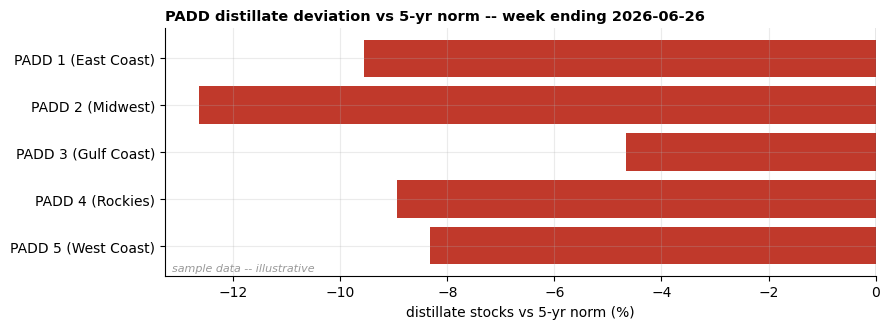

In [34]:
# ── PADD choropleth (with a bar-chart fallback that can never fail) ──────────
STATE_TO_PADD = {   # standard EIA definition (50 states + DC)
    # PADD 1 -- East Coast
    "CT": 1, "ME": 1, "MA": 1, "NH": 1, "RI": 1, "VT": 1, "NY": 1, "NJ": 1, "PA": 1,
    "DE": 1, "MD": 1, "DC": 1, "FL": 1, "GA": 1, "NC": 1, "SC": 1, "VA": 1, "WV": 1,
    # PADD 2 -- Midwest
    "IL": 2, "IN": 2, "IA": 2, "KS": 2, "KY": 2, "MI": 2, "MN": 2, "MO": 2, "NE": 2,
    "ND": 2, "OH": 2, "OK": 2, "SD": 2, "TN": 2, "WI": 2,
    # PADD 3 -- Gulf Coast
    "AL": 3, "AR": 3, "LA": 3, "MS": 3, "NM": 3, "TX": 3,
    # PADD 4 -- Rockies
    "CO": 4, "ID": 4, "MT": 4, "UT": 4, "WY": 4,
    # PADD 5 -- West Coast
    "AK": 5, "AZ": 5, "CA": 5, "HI": 5, "NV": 5, "OR": 5, "WA": 5,
}

def padd_bar_fallback():
    """The guaranteed-safe visual: five horizontal bars, red tight / blue loose."""
    labels = [f"PADD {n} ({p['name']})" for n, p in padd.items()]
    vals = [float(p["devpct"].iloc[-1]) for p in padd.values()]
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.barh(labels, vals, color=["#c0392b" if v < 0 else "#1a5fb4" for v in vals])
    ax.axvline(0, color="0.3", lw=0.9)
    ax.set_xlabel("distillate stocks vs 5-yr norm (%)")
    ax.set_title(f"PADD distillate deviation vs 5-yr norm -- week ending {d.index[-1].date()}",
                 loc="left", fontweight="bold", fontsize=10.5)
    ax.invert_yaxis()
    stamp(ax)
    save_show(fig, "padd_map_fallback.png")

MAP_PNG = CHART_DIR / "padd_map.png"
if MAP_PNG.exists():
    MAP_PNG.unlink()          # never let a stale export from a prior run reach the PDF

if not PADD_OK:
    print("PADD data unavailable -- map skipped.")
else:
    try:
        import plotly.express as px
        import plotly.io as pio
        # JSON-only renderer: keeps the saved notebook light (no embedded
        # plotly.js bundle). Renders in Jupyter/VS Code. GitHub's static viewer
        # can't run plotly either way; it gets the bar companion below whenever
        # PNG export is unavailable (else the PNG lands in charts/ and the PDF).
        pio.renderers.default = "plotly_mimetype"
        _asof = d.index[-1].date()
        rows = [dict(state=st,
                     padd=f"PADD {n} ({padd[n]['name']})",
                     dev_pct=float(padd[n]["devpct"].iloc[-1]),
                     stocks=float(padd[n]["s"].iloc[-1]),
                     norm=float(padd[n]["avg"].iloc[-1]),
                     dev_mb=float(padd[n]["dev"].iloc[-1]))
                for st, n in STATE_TO_PADD.items()]
        map_df = pd.DataFrame(rows)
        _rng = max(float(map_df["dev_pct"].abs().max()), 1.0)
        fig = px.choropleth(
            map_df, locations="state", locationmode="USA-states", scope="usa",
            color="dev_pct", color_continuous_scale="RdBu",   # red = tight, blue = loose
            range_color=(-_rng, _rng),
            custom_data=["padd", "stocks", "norm", "dev_mb", "dev_pct"],
            labels={"dev_pct": "% vs 5-yr norm"},
            title=(f"Distillate stocks vs 5-yr seasonal norm by PADD -- week ending {_asof}"
                   + ("   [sample data]" if DATA_MODE.startswith("SAMPLE") else "")))
        fig.update_traces(hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "stocks: %{customdata[1]:,.1f} Mb<br>"
            "5-yr norm: %{customdata[2]:,.1f} Mb<br>"
            "deviation: %{customdata[3]:+,.1f} Mb (%{customdata[4]:+.1f}%)<br>"
            f"week ending {_asof}<extra></extra>"))
        fig.update_layout(margin=dict(l=10, r=10, t=50, b=10),
                          coloraxis_colorbar=dict(title="% vs norm"))
        _png_ok = False
        try:      # PNG for the PDF only if the local kaleido/plotly pairing works
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fig.write_image(str(MAP_PNG), width=900, height=560, scale=2)
            _png_ok = True
            print(f"map PNG exported -> {MAP_PNG} (will be embedded in the PDF)")
        except Exception as e:
            print(f"(no static PNG export: {type(e).__name__} -- PDF skips the map; "
                  f"pair plotly/kaleido locally to enable it)")
        fig.show()
        if not _png_ok:
            # static companion so GitHub's viewer (which can't run plotly) and
            # the repo's chart folder still carry the regional picture
            padd_bar_fallback()
    except Exception as e:
        print(f"! choropleth failed ({type(e).__name__}: {e}) -- bar-chart fallback:")
        padd_bar_fallback()

# Phase 5 · The market view

Everything above collapses into an explicit, plain-English view — tight or loose, versus normal, and heading which way — plus a one-page PDF (`weekly_market_view.pdf`) regenerated on every run: the artifact you hand a manager or carry into an interview.

In [35]:
# ── Phase 5: turn the numbers into an explicit market view ───────────────────
def classify(devpct):
    return "TIGHT" if devpct < -4 else ("LOOSE" if devpct > 4 else "BALANCED")

def range_phrase(pos):
    if pos < 0:    return "below the bottom of its 5-yr range"
    if pos < 0.25: return "in the bottom quartile of its 5-yr range"
    if pos > 1:    return "above the top of its 5-yr range"
    if pos > 0.75: return "in the top quartile of its 5-yr range"
    return "inside its 5-yr range"

def market_view(d, snap, proj):
    i = d.index[-1]
    avg_cf, _, _ = seasonal_series(d.c_stk, proj["fut"])
    avg_tf, _, _ = seasonal_series(d.d_stk, proj["fut"])
    ec = float(proj["crude"].iloc[-1] - avg_cf.iloc[-1])   # end-horizon dev vs 5-yr avg
    et = float(proj["dist"].iloc[-1]  - avg_tf.iloc[-1])
    c, u, t = (snap.loc["Crude (comm., ex-SPR)"], snap.loc["Cushing"], snap.loc["Distillate"])
    horizon_end = proj["fut"][-1].date()

    trend = lambda now, end: (("widening" if abs(end) > abs(now) else "narrowing")
                              if end * now >= 0 else "flipping sign")
    mv = {}
    mv["asof"] = str(i.date())
    mv["crude_class"], mv["dist_class"] = classify(c["vs 5-yr avg (%)"]), classify(t["vs 5-yr avg (%)"])
    mv["crude_para"] = (
        f"Commercial crude stocks are {c['level (Mb)']:,.0f} Mb, {abs(c['vs 5-yr avg (Mb)']):,.0f} Mb "
        f"({abs(c['vs 5-yr avg (%)']):.0f}%) {'below' if c['vs 5-yr avg (Mb)'] < 0 else 'above'} the 5-yr "
        f"seasonal average and {range_phrase(c['pos in 5-yr range'])}. The last 4 weeks "
        f"{'drew' if c['4-wk D (Mb)'] < 0 else 'built'} {abs(c['4-wk D (Mb)']):,.0f} Mb. The baseline "
        f"projection has the deficit at {abs(ec):,.0f} Mb by {horizon_end} "
        f"({trend(c['vs 5-yr avg (Mb)'], ec)})." if c['vs 5-yr avg (Mb)'] < 0 else
        f"Commercial crude stocks are {c['level (Mb)']:,.0f} Mb, {c['vs 5-yr avg (Mb)']:,.0f} Mb above "
        f"the 5-yr average; projected {ec:+,.0f} Mb vs norm by {horizon_end}.")
    mv["cushing_line"] = (
        f"Cushing sits at {u['level (Mb)']:,.1f} Mb, {range_phrase(u['pos in 5-yr range'])} "
        f"({u['vs 5-yr avg (%)']:+.0f}% vs 5-yr avg) -- the WTI delivery point is "
        f"{'critically thin' if u['pos in 5-yr range'] < 0.1 else 'adequately supplied'}.")
    mv["dist_para"] = (
        f"Distillate stocks are {t['level (Mb)']:,.0f} Mb, {abs(t['vs 5-yr avg (Mb)']):,.0f} Mb "
        f"({abs(t['vs 5-yr avg (%)']):.0f}%) {'below' if t['vs 5-yr avg (Mb)'] < 0 else 'above'} the "
        f"5-yr average, {range_phrase(t['pos in 5-yr range'])}. 4-wk change: "
        f"{t['4-wk D (Mb)']:+,.0f} Mb. Baseline projection puts the gap at {et:+,.0f} Mb vs norm "
        f"by {horizon_end}, i.e. {'still well short of' if et < -4 else 'converging toward'} "
        f"normal ahead of the winter heating season.")
    bias_c = ("supportive of flat price and backwardated WTI structure" if mv["crude_class"] == "TIGHT"
              else "pressuring flat price and WTI structure" if mv["crude_class"] == "LOOSE"
              else "neutral for WTI structure")
    bias_t = ("constructive for diesel cracks and HO spreads" if mv["dist_class"] == "TIGHT"
              else "bearish diesel cracks" if mv["dist_class"] == "LOOSE"
              else "neutral for diesel cracks")
    mv["view_line"] = (f"MODEL VIEW: crude {mv['crude_class']} ({bias_c}); "
                       f"distillate {mv['dist_class']} ({bias_t}).")
    mv["caveat"] = ("Generated from SYNTHETIC sample data -- illustrative output only. "
                    "Connect a live EIA API key for the real current view."
                    if DATA_MODE.startswith("SAMPLE") else
                    "Generated from live EIA weekly data.")
    return mv

MV = market_view(d, snap, proj)
VIEW_TEXT = "\n\n".join([
    f"US CRUDE & DISTILLATE -- WEEKLY S/D VIEW   (week ending {MV['asof']})",
    MV["crude_para"], MV["cushing_line"], MV["dist_para"],
    REGIONAL_LINE,                       # Feature 2: the PADD 1 / P1-P3 sentence
    PRICE_LINE,                          # price context for the signal
    MV["view_line"],
    BT_HEADLINE,                         # Feature 1: the backtest headline
    MV["caveat"]])
print(VIEW_TEXT)

US CRUDE & DISTILLATE -- WEEKLY S/D VIEW   (week ending 2026-06-26)

Commercial crude stocks are 409 Mb, 31 Mb (7%) below the 5-yr seasonal average and below the bottom of its 5-yr range. The last 4 weeks drew 17 Mb. The baseline projection has the deficit at 40 Mb by 2026-09-18 (widening).

Cushing sits at 18.6 Mb, below the bottom of its 5-yr range (-40% vs 5-yr avg) -- the WTI delivery point is critically thin.

Distillate stocks are 107 Mb, 10 Mb (9%) below the 5-yr average, in the bottom quartile of its 5-yr range. 4-wk change: +4 Mb. Baseline projection puts the gap at -10 Mb vs norm by 2026-09-18, i.e. still well short of normal ahead of the winter heating season.

PADD 1 distillate 29.3 Mb, 3.1 Mb (10%) below its 5-yr norm -- NY Harbor tight, constructive for ULSD cracks; P1-P3 relative tightness -4.9 pts implies incentive to ship product east (Colonial-arb pull).

Prices: WTI $80.97/bbl, NYH ULSD $2.609/gal, diesel crack $28.61/bbl (+1.55 $/bbl over 4 wks).

MODEL VIEW: crude 

In [36]:
# ── The one-page weekly summary (PDF) -- the interview / manager artifact ────
def build_onepager(path=ONEPAGER):
    from reportlab.lib.pagesizes import letter
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Image,
                                    Table, TableStyle)
    from PIL import Image as PILImage

    styles = getSampleStyleSheet()
    small = ParagraphStyle("small", parent=styles["Normal"], fontSize=8.6, leading=11.6)
    h1 = ParagraphStyle("h1", parent=styles["Title"], fontSize=15, spaceAfter=2)
    sub = ParagraphStyle("sub", parent=styles["Normal"], fontSize=9, textColor=colors.grey)
    hd = ParagraphStyle("hd", parent=styles["Heading4"], fontSize=9.5, spaceBefore=6, spaceAfter=2)

    def img(fname, w_in):
        p = CHART_DIR / fname
        iw, ih = PILImage.open(p).size
        return Image(str(p), width=w_in * inch, height=w_in * inch * ih / iw)

    tbl = snap.round(1).reset_index().rename(columns={"index": ""})
    data = [list(tbl.columns)] + tbl.values.tolist()
    t = Table(data, hAlign="LEFT")
    t.setStyle(TableStyle([
        ("FONT", (0, 0), (-1, -1), "Helvetica", 7.4),
        ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", 7.4),
        ("LINEBELOW", (0, 0), (-1, 0), 0.6, colors.black),
        ("LINEBELOW", (0, -1), (-1, -1), 0.4, colors.grey),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.Color(0.96, 0.96, 0.96)]),
        ("TOPPADDING", (0, 0), (-1, -1), 1.6), ("BOTTOMPADDING", (0, 0), (-1, -1), 1.6),
    ]))

    doc = SimpleDocTemplate(str(path), pagesize=letter, topMargin=0.5 * inch,
                            bottomMargin=0.45 * inch, leftMargin=0.55 * inch,
                            rightMargin=0.55 * inch)
    story = [
        Paragraph("US Crude &amp; Distillate -- Weekly S/D Monitor", h1),
        Paragraph(f"Week ending {MV['asof']} &nbsp;|&nbsp; EIA Weekly Petroleum Status Report "
                  f"&nbsp;|&nbsp; {MV['caveat']}", sub),
        Spacer(1, 6),
        Paragraph("Inventory snapshot vs 5-year seasonal norm", hd), t, Spacer(1, 5),
        Table([[img("crude_inventories.png", 3.55), img("distillate_inventories.png", 3.55)]],
              hAlign="LEFT"),
        Paragraph("Crude", hd), Paragraph(MV["crude_para"], small),
        Paragraph(MV["cushing_line"], small),
        Paragraph("Distillate", hd), Paragraph(MV["dist_para"], small),
        Paragraph("View", hd),
        Paragraph(f"<b>{MV['view_line']}</b>", small),
        Paragraph("Regional &amp; signal check", hd),
        Paragraph(REGIONAL_LINE, small),
        Paragraph(f"{PRICE_LINE}  <b>{BT_HEADLINE}</b>", small), Spacer(1, 4),
        Paragraph(f"Method: weekly EIA balance (Supply - Demand = DInventory), inventory level vs "
                  f"trailing 5-yr seasonal average, {HORIZON_WEEKS}-week flow-based projection. "
                  f"Balance residual is tracked as a data-quality check only. PADD layer and "
                  f"price-signal backtest ride on the same seasonal framework (signal lagged 1 wk "
                  f"for WPSR publication).", sub),
    ]
    if (CHART_DIR / "padd_map.png").exists():   # only when kaleido export worked
        story.insert(-1, img("padd_map.png", 3.0))
    doc.build(story)
    print(f"One-pager written -> {path}")

try:
    build_onepager()
except ImportError as e:
    print(f"reportlab/Pillow not installed ({e}) -- run: pip install reportlab pillow")

One-pager written -> weekly_market_view.pdf


## Appendix

**Data traps this model deliberately avoids**

- *gross vs net imports* — both flows kept gross, on opposite sides of the balance
- *SPR-inclusive stocks* — `WCESTUS1` is commercial-only; SPR releases are policy noise
- *refinery inputs vs utilization* — the model uses the Mb/d volume, not the %
- *product supplied* — a demand proxy, and it sits on the demand side, never supply
- *regional detail* — PADD stocks are **components** of the national total: they power the regional view layer (PADD section above) but are never added as extra balance rows
- *Mb vs Mb/d* — every flow-to-stock conversion multiplies by 7, and units are documented per column

**Weekly workflow** — Wednesday 10:30am ET release → *Run All* → read the QA block → check the deviation chart and snapshot table → skim the adjustment line → send the regenerated one-pager.

**Roadmap** — full PADD-level *balances* (regional flows, not just stocks), gasoline as a third commodity, term-structure data (M1-M2 WTI / HO) so the backtest can target the curve as well as flat price, and cross-checking EIA export prints against vessel-tracking data of the kind desks use (Kpler / Vortexa).

## Run-locally checklist (after cloning, with network + an EIA key)

1. **Verify the 7 new series IDs** against the live API before trusting anything
   regional or price-based: run `python3 test_eia_key.py` (now loops all 18 IDs)
   and confirm each returns HTTP 200 with sane latest values. Any failure names
   the exact `PET.*.W` identifier to fix — candidates and fallbacks are in
   `DECISIONS.md` #13-14.
2. **Refresh the cache:** put the key in `.env` (`EIA_API_KEY=...`), *Run All*,
   confirm the banner says `LIVE (EIA API)` and QA passes (including the
   PADD-additivity check against `WDISTUS1`).
3. **Re-run the backtest on live data** — synthetic results validate the
   pipeline only. For the full 10-year sample set `START_DATE = "2009-01-01"`
   first (the 5-yr seasonal warm-up consumes the first five years).
4. **Sanity-check the scatters:** n in the hundreds, points cloud-like (not in
   stripes — stripes mean a stale/duplicated price series), COVID window
   visibly extreme, and the DECISIONS.md auto-block updated with live numbers.
5. Optional: `pip install -U plotly kaleido` as a compatible pair if you want
   the PADD map PNG embedded in the PDF (the notebook works fine without).